In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bharathgajula0821_stockdata_path = kagglehub.dataset_download('bharathgajula0821/stockdata')

print('Data source import complete.')


# Building an LSTM model to predict the price of the S&P 500

- LSTM stands for Long Short Term Memory

The LSTM cell contains an RNN cell inside (dense layer with a tanh activation function), but it has other attributes that allow it to remember patterns over a longer period of time. The LSTM contains a short-term state vector that is used from one time step to the next identical to the RNN cell.

Where LSTM cells differ is their Long-Term State vector. This long term state vector undergoes a multipicative and additive operation at each time step.The long term state vector starts off with a "forget gate" which is simply a sigmoid activation on top of a dense layer which produces an output from 0 - 1. This means if the forget gate ourputs a value of 1 then the long term state vector remains unchanged. On the opposite end, if the output valuse of the dense layer is 0 the long term state vector is nullified. This helps adjust quickly to highly volatile environments. If we are in a steady uptrend and then we suddenly have a big drop in the market, the long term state vector will be erased so the model can readjust quickly.

The next gate is the input gate. The input gate is much like the forget gate, except it decides if the short term state vector gets added to the long term vector or is erased.

The last gate called the "output gate" decides what the next hidden state should be. It is important to know that this hidden state output is the prediction for the next time step. Here, the previous hidden state (previous cell output) amd current input are jammed together through sigmoid function. Then we take our newly modified long term state vector which has already passed through the forget and input gates, and apply a tanh function to it. Finally, multiple both the tanh output (long term state vector output) and the sigmoid function output (previous hidden state and new input at this time step) to what information the hidden state needs to carry to the next time step.

</br>
<b>To review, the Forget gate decides what is relevant to keep from prior steps. The input gate decides what information is relevant to add from the current step. The output gate determines what the next hidden state should be.</b>

In [ ]:
!pip install yfinance -q
!pip install ta -q
!pip install mlflow -q
!pip install optuna-integration[tfkeras] -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 58.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 84.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import mlflow
import optuna
from optuna.integration import TFKerasPruningCallback
from tensorboard import notebook
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, LearningRateScheduler
import mlflow.tensorflow
from datetime import datetime, timedelta
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GRU, Bidirectional, GlobalAveragePooling1D, Flatten, Activation, RepeatVector, Permute, Multiply, Lambda, Input, Add
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from ta.trend import MACD, SMAIndicator, EMAIndicator, IchimokuIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, WilliamsRIndicator
from ta.volatility import BollingerBands, AverageTrueRate, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator, AccDistIndexIndicator, EaseOfMovementIndicator
from statsmodels.tsa.stattools import adfuller
import random
import tensorflow.keras.backend as K
import os
import joblib
import concurrent.futures
import warnings
from scipy.stats import spearmanr, pearsonr
from scipy.signal import find_peaks
import time
import json
from tensorflow.keras.utils import register_keras_serializable

warnings.filterwarnings('ignore')  # Suppress warnings

## Basic Data Setup and loading

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
keras = tf.keras

# set style of charts
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = [10, 10]

In [ ]:
def plot_series(time, series, format="-", start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)


def sequential_window_dataset(series, window_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=window_size, drop_remainder=True)
    ds = ds.flat_map(lambda window: window.batch(window_size + 1))
    ds = ds.map(lambda window: (window[:-1], window[1:]))
    return ds.batch(1).prefetch(1)

In [ ]:
file_path = '/kaggle/input/stockdata/stock_data.csv'
stock_df = pd.read_csv(file_path, skiprows=2, header=None)

stock_df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')
stock_df = stock_df.dropna(subset=['Date'])  # Remove rows with invalid dates
stock_df = stock_df.set_index('Date')

# Print some info
print(stock_df.head())
print(stock_df.tail())
print("\nDataFrame columns:")
print(stock_df.columns)

                  Close         High          Low         Open        Volume
Date                                                                        
2000-01-03  1455.219971  1478.000000  1438.359985  1469.250000  9.318000e+08
2000-01-04  1399.420044  1455.219971  1397.430054  1455.219971  1.009000e+09
2000-01-05  1402.109985  1413.270020  1377.680054  1399.420044  1.085500e+09
2000-01-06  1403.449951  1411.900024  1392.099976  1402.109985  1.092300e+09
2000-01-07  1441.469971  1441.469971  1400.729980  1403.449951  1.225200e+09
                  Close         High          Low         Open        Volume
Date                                                                        
2024-12-24  6040.040039  6040.100098  5981.439941  5984.629883  1.757720e+09
2024-12-26  6037.589844  6049.750000  6007.370117  6024.970215  2.904530e+09
2024-12-27  5970.839844  6006.169922  5932.950195  6006.169922  3.159610e+09
2024-12-30  5906.939941  5940.790039  5869.160156  5920.669922  3.433250e+09

/tmp/ipykernel_31/1089632973.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')


In [ ]:
display(stock_df.describe())
display(stock_df.shape)

,Close,High,Low,Open,Volume
count,6289.000000,6289.000000,6289.000000,6289.000000,6.289000e+03
mean,2112.014193,2123.846701,2098.696135,2111.727483,3.351107e+09
std,1243.313309,1248.723568,1237.150430,1243.102750,1.490823e+09
min,676.530029,695.270020,666.789978,679.280029,3.560700e+08
25%,1200.819946,1207.609985,1192.640015,1200.750000,2.197010e+09
50%,1491.560059,1499.099976,1480.280029,1491.469971,3.482580e+09
75%,2748.929932,2764.409912,2736.060059,2752.909912,4.158800e+09
max,6090.270020,6099.970215,6079.979980,6089.029785,1.145623e+10


(6289, 5)

In [ ]:
BASE_DIR = '/content/drive/MyDrive/data_capstone/LSTM_ARO_MODEL'
os.makedirs(BASE_DIR, exist_ok=True)

# Create subdirectories for organization
MODEL_DIR = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
LOGS_DIR = os.path.join(BASE_DIR, 'logs')
EDA_DIR = os.path.join(BASE_DIR, 'eda_plots')

# Create all directories
for directory in [MODEL_DIR, RESULTS_DIR, LOGS_DIR, EDA_DIR]:
    os.makedirs(directory, exist_ok=True)

print(f"Directories created in Google Drive at {BASE_DIR}")

Directories created in Google Drive at /content/drive/MyDrive/data_capstone/LSTM_ARO_MODEL


In [ ]:
# Configure MLflow to store artifacts in Google Drive
os.environ["MLFLOW_TRACKING_URI"] = os.path.join(BASE_DIR, 'mlruns')
mlflow.set_experiment("LSTM-ARO-Stock-Prediction-GPU-Enhanced")


2025/04/11 03:46:21 INFO mlflow.tracking.fluent: Experiment with name 'LSTM-ARO-Stock-Prediction-GPU-Enhanced' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/drive/MyDrive/data_capstone/LSTM_ARO_MODEL/mlruns/326418973471146596', creation_time=1744343181167, experiment_id='326418973471146596', last_update_time=1744343181167, lifecycle_stage='active', name='LSTM-ARO-Stock-Prediction-GPU-Enhanced', tags={}>

In [ ]:
def perform_eda(data):
    """
    Perform exploratory data analysis on the S&P 500 data
    """
    print("\n=== Exploratory Data Analysis ===")

    # Create a directory for EDA plots
    os.makedirs('eda_plots', exist_ok=True)

    # Basic statistics
    print("\nBasic Statistics:")
    print(data.describe())

    # Check for missing values
    print("\nMissing Values:")
    print(data.isnull().sum())

    # Distribution of returns
    daily_returns = data['Close'].pct_change().dropna()

    # Plot price history
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'])
    plt.title('S&P 500 Price History')
    plt.ylabel('Price ($)')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/price_history.png'))
    plt.show()

    # Plot daily returns
    plt.figure(figsize=(12, 6))
    plt.plot(daily_returns.index, daily_returns)
    plt.title('S&P 500 Daily Returns')
    plt.ylabel('Return (%)')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/daily_returns.png'))
    plt.show()

    # Daily returns distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(daily_returns, kde=True)
    plt.title('Distribution of Daily Returns')
    plt.xlabel('Daily Return')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/returns_distribution.png'))
    plt.show()

    # Check for stationarity
    print("\nAugmented Dickey-Fuller Test (for stationarity):")
    adf_result = adfuller(daily_returns)
    print(f'ADF Statistic: {adf_result[0]}')
    print(f'p-value: {adf_result[1]}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value}')

    # Autocorrelation plot
    plt.figure(figsize=(12, 6))
    pd.plotting.autocorrelation_plot(daily_returns)
    plt.title('Autocorrelation of Daily Returns')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/autocorrelation.png'))
    plt.show()

    # Volume analysis
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Volume'])
    plt.title('Trading Volume')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/volume.png'))
    plt.show()

    # Price vs Volume correlation
    plt.figure(figsize=(12, 6))
    plt.scatter(daily_returns, data['Volume'][1:] / 1e9)
    plt.title('Returns vs Volume')
    plt.xlabel('Daily Return')
    plt.ylabel('Volume (Billions)')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/returns_vs_volume.png'))
    plt.show()

    # Seasonal patterns (day of week, month)
    data['DayOfWeek'] = data.index.dayofweek
    data['Month'] = data.index.month

    # Average return by day of week
    day_of_week_returns = daily_returns.groupby(daily_returns.index.dayofweek).mean()
    plt.figure(figsize=(10, 6))
    plt.bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'], day_of_week_returns)
    plt.title('Average Return by Day of Week')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/dayofweek_returns.png'))
    plt.show()

    # Average return by month
    month_returns = daily_returns.groupby(daily_returns.index.month).mean()
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, 13), month_returns)
    plt.title('Average Return by Month')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/month_returns.png'))
    plt.show()

    # Volatility clustering
    rolling_std = daily_returns.rolling(window=21).std()
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_std)
    plt.title('21-Day Rolling Volatility')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/volatility_clustering.png'))
    plt.show()

    # Look for market regimes using volatility
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(data.index, data['Close'])
    plt.title('S&P 500 Price')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(rolling_std.index, rolling_std)
    plt.title('21-Day Rolling Volatility')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/market_regimes.png'))
    plt.show()

    # Identify market peaks and troughs
    price_series = data['Close'].values
    peaks, _ = find_peaks(price_series, distance=20)  # Minimum distance between peaks (days)
    troughs, _ = find_peaks(-price_series, distance=20)

    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'])
    plt.scatter(data.index[peaks], data['Close'].iloc[peaks], color='green', s=50, marker='^')
    plt.scatter(data.index[troughs], data['Close'].iloc[troughs], color='red', s=50, marker='v')
    plt.title('S&P 500 with Identified Peaks and Troughs')
    plt.grid(True)
    plt.savefig(os.path.join(BASE_DIR, 'eda_plots/peaks_troughs.png'))
    plt.show()

    # Return the enhanced dataframe for further analysis
    return data


=== Exploratory Data Analysis ===

Basic Statistics:
             Close         High          Low         Open        Volume
count  6289.000000  6289.000000  6289.000000  6289.000000  6.289000e+03
mean   2112.014193  2123.846701  2098.696135  2111.727483  3.351107e+09
std    1243.313309  1248.723568  1237.150430  1243.102750  1.490823e+09
min     676.530029   695.270020   666.789978   679.280029  3.560700e+08
25%    1200.819946  1207.609985  1192.640015  1200.750000  2.197010e+09
50%    1491.560059  1499.099976  1480.280029  1491.469971  3.482580e+09
75%    2748.929932  2764.409912  2736.060059  2752.909912  4.158800e+09
max    6090.270020  6099.970215  6079.979980  6089.029785  1.145623e+10

Missing Values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


NameError: name 'BASE_DIR' is not defined

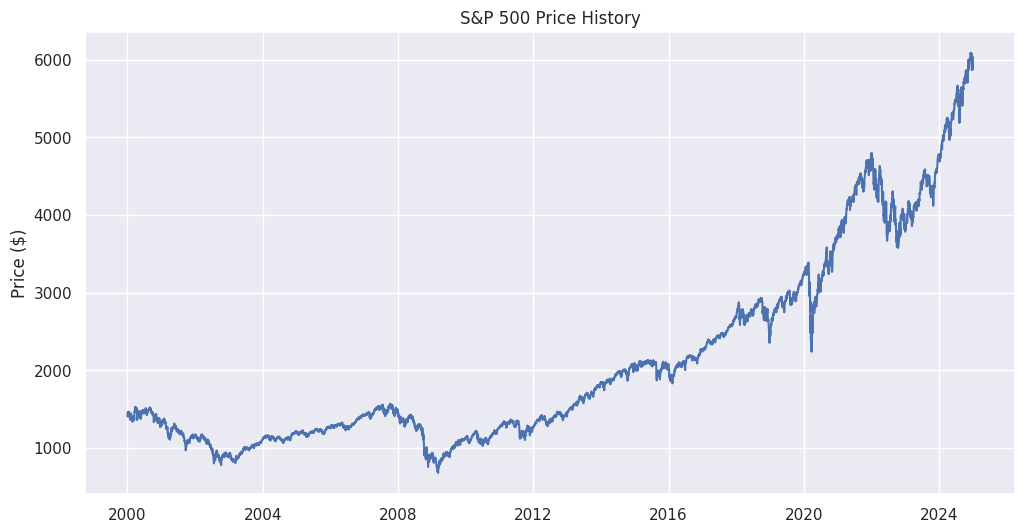

In [ ]:
perform_eda(stock_df)


In [ ]:
def add_technical_indicators(data):
    """Add various technical indicators to the dataframe"""
    print("Adding technical indicators...")
    df = data.copy()

    # Price Transformations
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Price_Change'] = df['Close'].pct_change()

    # Time-based features
    df['Day_of_Week'] = df.index.dayofweek
    df['Month'] = df.index.month
    df['Quarter'] = df.index.quarter

    # Trend Indicators
    df['SMA_5'] = SMAIndicator(close=df['Close'], window=5).sma_indicator()
    df['SMA_10'] = SMAIndicator(close=df['Close'], window=10).sma_indicator()
    df['SMA_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
    df['SMA_50'] = SMAIndicator(close=df['Close'], window=50).sma_indicator()
    df['SMA_200'] = SMAIndicator(close=df['Close'], window=200).sma_indicator()

    df['EMA_5'] = EMAIndicator(close=df['Close'], window=5).ema_indicator()
    df['EMA_10'] = EMAIndicator(close=df['Close'], window=10).ema_indicator()
    df['EMA_20'] = EMAIndicator(close=df['Close'], window=20).ema_indicator()
    df['EMA_50'] = EMAIndicator(close=df['Close'], window=50).ema_indicator()
    df['EMA_200'] = EMAIndicator(close=df['Close'], window=200).ema_indicator()

    # Deviation from moving averages (normalized)
    df['Deviation_SMA_20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
    df['Deviation_SMA_50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
    df['Deviation_SMA_200'] = (df['Close'] - df['SMA_200']) / df['SMA_200']

    # Moving average crossover signals
    df['SMA_5_10_Crossover'] = (df['SMA_5'] > df['SMA_10']).astype(int)
    df['SMA_10_20_Crossover'] = (df['SMA_10'] > df['SMA_20']).astype(int)
    df['SMA_20_50_Crossover'] = (df['SMA_20'] > df['SMA_50']).astype(int)
    df['SMA_50_200_Crossover'] = (df['SMA_50'] > df['SMA_200']).astype(int)

    # MACD
    macd = MACD(close=df['Close'])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Diff'] = macd.macd_diff()
    df['MACD_Crossover'] = ((df['MACD'] > df['MACD_Signal']).astype(int) -
                           (df['MACD'] < df['MACD_Signal']).astype(int))

    # Momentum Indicators
    df['RSI_14'] = RSIIndicator(close=df['Close'], window=14).rsi()
    df['RSI_7'] = RSIIndicator(close=df['Close'], window=7).rsi()

    # Stochastic oscillator
    stoch = StochasticOscillator(high=df['High'], low=df['Low'], close=df['Close'], window=14, smooth_window=3)
    df['Stoch_k'] = stoch.stoch()
    df['Stoch_d'] = stoch.stoch_signal()
    df['Stoch_Crossover'] = ((df['Stoch_k'] > df['Stoch_d']).astype(int) -
                            (df['Stoch_k'] < df['Stoch_d']).astype(int))

    # Williams %R
    df['Williams_%R_14'] = WilliamsRIndicator(high=df['High'], low=df['Low'], close=df['Close'], lbp=14).williams_r()

    # Volatility Indicators
    bb = BollingerBands(close=df['Close'])
    df['BB_Upper'] = bb.bollinger_hband()
    df['BB_Lower'] = bb.bollinger_lband()
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['Close']
    df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

    df['ATR_14'] = AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()
    df['ATR_Percent'] = df['ATR_14'] / df['Close'] * 100

    # Volume Indicators
    df['OBV'] = OnBalanceVolumeIndicator(close=df['Close'], volume=df['Volume']).on_balance_volume()
    df['ADI'] = AccDistIndexIndicator(high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume']).acc_dist_index()
    df['EMV'] = EaseOfMovementIndicator(high=df['High'], low=df['Low'], volume=df['Volume']).ease_of_movement()

    # Volume-based features
    df['Volume_Change'] = df['Volume'].pct_change()
    df['Volume_SMA_5'] = SMAIndicator(close=df['Volume'], window=5).sma_indicator()
    df['Volume_Ratio_5'] = df['Volume'] / df['Volume_SMA_5']

    # Ichimoku Cloud
    ichimoku = IchimokuIndicator(high=df['High'], low=df['Low'])
    df['Ichimoku_a'] = ichimoku.ichimoku_a()
    df['Ichimoku_b'] = ichimoku.ichimoku_b()
    df['Ichimoku_Trend'] = ((df['Close'] > df['Ichimoku_a']) & (df['Close'] > df['Ichimoku_b'])).astype(int)

    # Target variable: Next day direction (1 if price goes up, 0 if price goes down)
    df['Next_Day_Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Drop NaN values
    df = df.dropna()

    print(f"Added {len(df.columns) - len(data.columns)} technical indicators")
    return df

In [ ]:
enhanced_df = add_technical_indicators(stock_df)
display(enhanced_df.tail())

Adding technical indicators...
Added 48 technical indicators


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/comput

,Close,High,Low,Open,Volume,Log_Returns,Price_Change,Day_of_Week,Month,Quarter,...,OBV,ADI,EMV,Volume_Change,Volume_SMA_5,Volume_Ratio_5,Ichimoku_a,Ichimoku_b,Ichimoku_Trend,Next_Day_Direction
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1.757720e+09,0.010982,0.011043,1,12,4,...,1.409735e+12,2.133732e+12,234.811853,-0.510831,4.743612e+09,0.370545,5962.439941,5898.23999,1,0
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2.904530e+09,-0.000406,-0.000406,3,12,4,...,1.406830e+12,2.134970e+12,25.957376,0.652442,4.275126e+09,0.679402,5962.439941,5898.23999,1,0
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3.159610e+09,-0.011117,-0.011056,4,12,4,...,1.403671e+12,2.135080e+12,-136.724592,0.087821,3.927672e+09,0.804449,5962.439941,5898.23999,1,0
2024-12-30,5906.939941,5940.790039,5869.160156,5920.669922,3.433250e+09,-0.010760,-0.010702,0,12,4,...,1.400238e+12,2.135268e+12,-134.747344,0.086606,2.969678e+09,1.156102,5958.809937,5898.23999,0,0
2024-12-31,5881.629883,5929.740234,5868.859863,5919.740234,3.128350e+09,-0.004294,-0.004285,1,12,4,...,1.397109e+12,2.133452e+12,-11.044131,-0.088808,2.876692e+09,1.087482,5958.809937,5898.23999,0,0


In [ ]:
total_data_points = len(enhanced_df)
train_split_index = int(total_data_points * 0.65)  # 60% for training
valid_split_index = int(total_data_points * 0.8)  # 80% for training + validation
test_split_index = int(total_data_points * 1)  # 100% for testing

train_data = enhanced_df[:train_split_index]
valid_data = enhanced_df[train_split_index:valid_split_index]
test_data = enhanced_df[valid_split_index:]

print(f"Train data shape: {train_data.shape}")
print(f"Validation data shape: {valid_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (3958, 53)
Validation data shape: (914, 53)
Test data shape: (1218, 53)


## Best Dual Model - Final Optimization

### Prepaing the Lstm and data sequence

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPUs and configured memory growth")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")

def prepare_data_sequences(train_data, valid_data, test_data, sequence_length=60, prediction_horizon=1,
                          use_log_transform=True, use_robust_scaler=True):
    """
    Prepare sequence data for LSTM/GRU models with both price and direction prediction.
    Enhanced with log transformation and robust scaling options for price data.
    """
    print(f"Preparing data with sequence length {sequence_length}...")
    train_data = train_data.copy()
    valid_data = valid_data.copy()
    test_data = test_data.copy()

    for df in [train_data, valid_data, test_data]:
        if 'Next_Day_Direction' not in df.columns:
            df['Next_Day_Direction'] = (df['Close'].shift(-prediction_horizon) > df['Close']).astype(int)
        if 'Next_Day_Price' not in df.columns:
            df['Next_Day_Price'] = df['Close'].shift(-prediction_horizon)

    train_data = train_data.dropna()
    valid_data = valid_data.dropna()
    test_data = test_data.dropna()

    # Define columns for targets and features
    direction_col = 'Next_Day_Direction'
    price_col = 'Next_Day_Price'
    feature_cols = [col for col in train_data.columns if col not in [direction_col, price_col]]

    feature_scaler = StandardScaler()
    feature_scaler.fit(train_data[feature_cols])

    scaled_train_features = feature_scaler.transform(train_data[feature_cols]).astype(np.float32)
    scaled_valid_features = feature_scaler.transform(valid_data[feature_cols]).astype(np.float32)
    scaled_test_features = feature_scaler.transform(test_data[feature_cols]).astype(np.float32)

    # Process price data with enhanced techniques
    if use_log_transform:
        print("Using log transformation for price data")
        # Apply log transform to price data (ensuring all values are positive)
        train_prices = np.log(train_data[[price_col]].values)
        valid_prices = np.log(valid_data[[price_col]].values)
        test_prices = np.log(test_data[[price_col]].values)
    else:
        train_prices = train_data[[price_col]].values
        valid_prices = valid_data[[price_col]].values
        test_prices = test_data[[price_col]].values

    if use_robust_scaler:
        from sklearn.preprocessing import RobustScaler
        print("Using RobustScaler for price data")
        price_scaler = RobustScaler()
    else:
        print("Using MinMaxScaler for price data")
        price_scaler = MinMaxScaler(feature_range=(0, 1))

    price_scaler.fit(train_prices)

    scaled_train_prices = price_scaler.transform(train_prices).flatten().astype(np.float32)
    scaled_valid_prices = price_scaler.transform(valid_prices).flatten().astype(np.float32)
    scaled_test_prices = price_scaler.transform(test_prices).flatten().astype(np.float32)

    def create_sequences(features, direction_values, price_values, seq_length):
        total_sequences = len(features) - seq_length - prediction_horizon + 1
        X = np.zeros((total_sequences, seq_length, features.shape[1]), dtype=np.float32)
        y_dir = np.zeros(total_sequences, dtype=np.int32)
        y_price = np.zeros(total_sequences, dtype=np.float32)

        for i in range(total_sequences):
            X[i] = features[i:i+seq_length]
            idx = i + seq_length + prediction_horizon - 1
            if idx < len(direction_values):
                y_dir[i] = direction_values[idx]
                y_price[i] = price_values[idx]

        return X, y_dir, y_price

    train_dir = train_data[direction_col].values
    valid_dir = valid_data[direction_col].values
    test_dir = test_data[direction_col].values

    X_train, y_train_dir, y_train_price = create_sequences(scaled_train_features, train_dir, scaled_train_prices, sequence_length)
    X_val, y_val_dir, y_val_price = create_sequences(scaled_valid_features, valid_dir, scaled_valid_prices, sequence_length)
    X_test, y_test_dir, y_test_price = create_sequences(scaled_test_features, test_dir, scaled_test_prices, sequence_length)

    print(f"Train data shape: {X_train.shape}")
    print(f"Validation data shape: {X_val.shape}")
    print(f"Test data shape: {X_test.shape}")

    total_samples = len(y_train_dir)
    n_positive = np.sum(y_train_dir)
    n_negative = total_samples - n_positive
    class_weight = {
        0: total_samples / (2.0 * n_negative),
        1: total_samples / (2.0 * n_positive)
    }
    print(f"Class distribution - Up: {n_positive}/{total_samples} ({n_positive/total_samples:.2f}), "
          f"Down: {n_negative}/{total_samples} ({n_negative/total_samples:.2f})")
    print(f"Class weights: {class_weight}")

    # Store transformation parameters for later inverse transform
    transform_params = {
        'log_transform': use_log_transform,
        'robust_scaler': use_robust_scaler
    }
    print("Saving scalers to disk...")
    joblib.dump(feature_scaler, 'models/feature_scaler.pkl')
    joblib.dump(price_scaler, 'models/price_scaler.pkl')

    joblib.dump(transform_params, 'models/transform_params.pkl')

    print("Scalers and transform parameters saved successfully")

    return (X_train, y_train_dir, y_train_price,
            X_val, y_val_dir, y_val_price,
            X_test, y_test_dir, y_test_price,
            feature_scaler, price_scaler, feature_cols, class_weight, transform_params)

def create_attention_layer(x, num_dense_units=64):
    """Creates an attention mechanism for sequence data."""
    attention = Dense(num_dense_units, activation='tanh')(x)
    attention = BatchNormalization()(attention)
    attention = Dense(1, activation=None)(attention)
    attention_weights = Flatten()(attention)
    attention_weights = Activation('softmax')(attention_weights)
    attention_weights = RepeatVector(K.int_shape(x)[2])(attention_weights)
    attention_weights = Permute([2, 1])(attention_weights)
    weighted_output = Multiply()([x, attention_weights])

    context_vector = GlobalAveragePooling1D()(weighted_output)

    return context_vector, attention_weights



Found 1 GPUs and configured memory growth


### 3. Multi-Layer Direction Model Builder with Optuna


In [ ]:

# 3. Multi-Layer Direction Model Builder with Optuna
def build_direction_model_optuna(trial, input_shape):
    """
    Build a multi-layer direction prediction model with Optuna hyperparameters.
    """
    # Number of recurrent layers: 2 or 3
    n_layers = trial.suggest_int('n_layers', 2, 3)

    inputs = Input(shape=input_shape)

    # Layer 1: Expanded units range and dropout with step size
    layer1_type = trial.suggest_categorical('layer1_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
    layer1_units = trial.suggest_int('layer1_units', 64, 512)
    if layer1_type == 'LSTM':
        x = LSTM(units=layer1_units, return_sequences=True)(inputs)
    elif layer1_type == 'BiLSTM':
        x = Bidirectional(LSTM(units=layer1_units // 2, return_sequences=True))(inputs)
    elif layer1_type == 'GRU':
        x = GRU(units=layer1_units, return_sequences=True)(inputs)
    elif layer1_type == 'BiGRU':
        x = Bidirectional(GRU(units=layer1_units // 2, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dropout1', 0.1, 0.5, step=0.05))(x)

    # Layer 2
    layer2_type = trial.suggest_categorical('layer2_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
    layer2_units = trial.suggest_int('layer2_units', 32, 256)
    use_attention = trial.suggest_categorical('use_attention', [True, False])
    return_sequences = (n_layers > 2) or use_attention  # Return sequences if there's a third layer or attention
    if layer2_type == 'LSTM':
        x = LSTM(units=layer2_units, return_sequences=return_sequences)(x)
    elif layer2_type == 'BiLSTM':
        x = Bidirectional(LSTM(units=layer2_units // 2, return_sequences=return_sequences))(x)
    elif layer2_type == 'GRU':
        x = GRU(units=layer2_units, return_sequences=return_sequences)(x)
    elif layer2_type == 'BiGRU':
        x = Bidirectional(GRU(units=layer2_units // 2, return_sequences=return_sequences))(x)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dropout2', 0.1, 0.5, step=0.05))(x)

    # Optional Third Layer if n_layers > 2
    if n_layers > 2:
        layer3_type = trial.suggest_categorical('layer3_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
        layer3_units = trial.suggest_int('layer3_units', 16, 64)
        if layer3_type == 'LSTM':
            x = LSTM(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == 'BiLSTM':
            x = Bidirectional(LSTM(units=layer3_units // 2, return_sequences=use_attention))(x)
        elif layer3_type == 'GRU':
            x = GRU(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == 'BiGRU':
            x = Bidirectional(GRU(units=layer3_units // 2, return_sequences=use_attention))(x)
        x = BatchNormalization()(x)
        x = Dropout(trial.suggest_float('dropout3', 0.1, 0.5, step=0.05))(x)

    # Add attention mechanism if specified
    if use_attention and return_sequences:
        x, _ = create_attention_layer(x, num_dense_units=trial.suggest_int('attention_units', 32, 128))

    # Dense block
    dense_units = trial.suggest_int('dense_units', 16, 64)
    x = Dense(dense_units, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dense_dropout', 0.1, 0.4, step=0.05))(x)

    outputs = Dense(1, activation='sigmoid', name='direction_output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Learning rate and optimizer choice
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_choice = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'nadam'])
    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    return model

# 4. Multi-Layer Price Model Builder with Optuna
def build_price_model_optuna(trial, input_shape):
    """
    Build a multi-layer price prediction model with Optuna hyperparameters.
    """
    n_layers = trial.suggest_int('n_layers', 2, 3)
    inputs = Input(shape=input_shape)

    # Layer 1: Increased unit range
    layer1_type = trial.suggest_categorical('layer1_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
    layer1_units = trial.suggest_int('layer1_units', 128, 512)
    if layer1_type == 'LSTM':
        x = LSTM(units=layer1_units, return_sequences=True)(inputs)
    elif layer1_type == 'BiLSTM':
        x = Bidirectional(LSTM(units=layer1_units // 2, return_sequences=True))(inputs)
    elif layer1_type == 'GRU':
        x = GRU(units=layer1_units, return_sequences=True)(inputs)
    elif layer1_type == 'BiGRU':
        x = Bidirectional(GRU(units=layer1_units // 2, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dropout1', 0.1, 0.5, step=0.05))(x)

    # Layer 2
    layer2_type = trial.suggest_categorical('layer2_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
    layer2_units = trial.suggest_int('layer2_units', 64, 256)
    use_attention = trial.suggest_categorical('use_attention', [True, False])
    return_sequences = (n_layers > 2) or use_attention
    if layer2_type == 'LSTM':
        x = LSTM(units=layer2_units, return_sequences=return_sequences)(x)
    elif layer2_type == 'BiLSTM':
        x = Bidirectional(LSTM(units=layer2_units // 2, return_sequences=return_sequences))(x)
    elif layer2_type == 'GRU':
        x = GRU(units=layer2_units, return_sequences=return_sequences)(x)
    elif layer2_type == 'BiGRU':
        x = Bidirectional(GRU(units=layer2_units // 2, return_sequences=return_sequences))(x)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dropout2', 0.1, 0.5, step=0.05))(x)

    # Optional Third Layer if n_layers > 2
    if n_layers > 2:
        layer3_type = trial.suggest_categorical('layer3_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU'])
        layer3_units = trial.suggest_int('layer3_units', 32, 128)
        if layer3_type == 'LSTM':
            x = LSTM(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == 'BiLSTM':
            x = Bidirectional(LSTM(units=layer3_units // 2, return_sequences=use_attention))(x)
        elif layer3_type == 'GRU':
            x = GRU(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == 'BiGRU':
            x = Bidirectional(GRU(units=layer3_units // 2, return_sequences=use_attention))(x)
        x = BatchNormalization()(x)
        x = Dropout(trial.suggest_float('dropout3', 0.1, 0.5, step=0.05))(x)

    if use_attention and return_sequences:
        x, _ = create_attention_layer(x, num_dense_units=trial.suggest_int('attention_units', 64, 256))

    # Dense layers block for price prediction
    x = Dense(trial.suggest_int('dense_units1', 64, 256), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dense_dropout1', 0.1, 0.3, step=0.05))(x)

    x = Dense(trial.suggest_int('dense_units2', 32, 128), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(trial.suggest_float('dense_dropout2', 0.1, 0.3, step=0.05))(x)

    outputs = Dense(1, activation='linear', name='price_output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-2, log=True)
    loss_type = trial.suggest_categorical('loss_type', ['mse', 'mae', 'huber'])

    optimizer_choice = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'nadam'])
    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss_type,
        metrics=['mae', 'mse']
    )

    return model


class DelayedPruningCallback(TFKerasPruningCallback):
    def __init__(self, trial, monitor, delay=3):
        super().__init__(trial, monitor)
        self.delay = delay

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.delay:
            super().on_epoch_end(epoch, logs)
# 5. Objective Function for Direction Model
def objective_direction_model(trial, X_train, y_train, X_val, y_val, class_weight, input_shape):
    """Objective function for direction model optimization."""
    try:
        model = build_direction_model_optuna(trial, input_shape)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])




        early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=0)
        pruning_callback = DelayedPruningCallback(trial, 'val_accuracy', delay=3)

        # Adjust sample weights for class imbalance
        sample_weights = np.ones(len(y_train))
        for cls, weight in class_weight.items():
            sample_weights[y_train == cls] = weight

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,  # Short training for optimization
            batch_size=batch_size,
            sample_weight=sample_weights,
            callbacks=[early_stopping, pruning_callback],
            verbose=0
        )

        y_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        val_f1 = f1_score(y_val.flatten(), y_pred)

        # Print model summary for debugging purposes
        model.summary()

        del model
        K.clear_session()

        return val_f1

    except Exception as e:
        print(f"Error in direction model trial: {str(e)}")
        K.clear_session()
        return float('-inf')

# 6. Objective Function for Price Model
def objective_price_model(trial, X_train, y_train, X_val, y_val, input_shape):
    """Objective function for price model optimization."""
    try:
        model = build_price_model_optuna(trial, input_shape)
        batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

        early_stopping = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True, mode='min', verbose=0)
        pruning_callback = DelayedPruningCallback(trial, 'val_mae', delay=3)


        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=batch_size,
            callbacks=[early_stopping, pruning_callback],
            verbose=0
        )

        val_mae = min(history.history['val_mae'])
        model.summary()

        del model
        K.clear_session()

        return val_mae

    except Exception as e:
        print(f"Error in price model trial: {str(e)}")
        K.clear_session()
        return float('inf')

# 7. Main Function to Run Optimization
def multi_layer_model_optimization(train_data, valid_data, test_data, sequence_length=60, prediction_horizon=1):
    """
    Run multi-layer model architecture optimization using Optuna.
    """
    os.makedirs('models', exist_ok=True)
    os.makedirs('results', exist_ok=True)

    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     feature_scaler, price_scaler, feature_cols, class_weight) = prepare_data_sequences(
        train_data, valid_data, test_data, sequence_length, prediction_horizon
    )

    # Save scalers for later use
    joblib.dump(feature_scaler, 'models/feature_scaler.pkl')
    joblib.dump(price_scaler, 'models/price_scaler.pkl')

    input_shape = (X_train.shape[1], X_train.shape[2])

    # Define common sampler and pruner for robust exploration
    sampler = optuna.samplers.TPESampler(seed=42, multivariate=True,warn_independent_sampling=False)
    pruner = optuna.pruners.HyperbandPruner()
    direction_sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
    price_sampler = optuna.samplers.TPESampler(seed=42, multivariate=True,warn_independent_sampling=False)


    # 1. Direction Model Optimization (increased trials)
    print("\n=== Starting Multi-Layer Direction Model Optimization ===")
    direction_study = optuna.create_study(
        study_name="multi_layer_direction_model",
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        storage="sqlite:///multi_layer_optuna.db",
        load_if_exists=True
    )

    direction_objective = lambda trial: objective_direction_model(
        trial, X_train, y_train_dir, X_val, y_val_dir, class_weight, input_shape
    )

    n_direction_trials = 150  # Increased number of trials for thorough exploration
    print(f"Running {n_direction_trials} trials for direction model...")
    direction_study.optimize(
        direction_objective,
        n_trials=n_direction_trials,
        timeout=3600 * 2,  # Up to 2 hours maximum
        n_jobs=1,
        catch=(Exception,),
        show_progress_bar=True
    )

    print("\n=== Direction Model Optimization Results ===")
    print(f"Best trial: {direction_study.best_trial.number}")
    print(f"Best F1 score: {direction_study.best_value:.4f}")
    for key, value in direction_study.best_params.items():
        print(f"  {key}: {value}")

    with open('results/multi_layer_direction_best_params.json', 'w') as f:
        json.dump({
            'best_trial': direction_study.best_trial.number,
            'best_f1': float(direction_study.best_value),
            'best_params': direction_study.best_params
        }, f, indent=4)

    # 2. Price Model Optimization (increased trials)
    print("\n=== Starting Multi-Layer Price Model Optimization ===")
    price_study = optuna.create_study(
        study_name="multi_layer_price_model",
        direction="minimize",
        sampler=price_sampler,
        pruner=pruner,
        storage="sqlite:///multi_layer_optuna.db",
        load_if_exists=True
    )

    price_objective = lambda trial: objective_price_model(
        trial, X_train, y_train_price, X_val, y_val_price, input_shape
    )

    n_price_trials = 150  # Increased number of trials
    print(f"Running {n_price_trials} trials for price model...")
    price_study.optimize(
        price_objective,
        n_trials=n_price_trials,
        timeout=3600 * 2,
        n_jobs=1,
        catch=(Exception,),
        show_progress_bar=True
    )

    print("\n=== Price Model Optimization Results ===")
    print(f"Best trial: {price_study.best_trial.number}")
    print(f"Best MAE: {price_study.best_value:.4f}")
    for key, value in price_study.best_params.items():
        print(f"  {key}: {value}")

    with open('results/multi_layer_price_best_params.json', 'w') as f:
        json.dump({
            'best_trial': price_study.best_trial.number,
            'best_mae': float(price_study.best_value),
            'best_params': price_study.best_params
        }, f, indent=4)

    # Optional: Save visualizations (if running in an interactive environment)
    try:
        fig_history = optuna.visualization.plot_optimization_history(direction_study)
        fig_importance = optuna.visualization.plot_param_importances(direction_study)
        fig_history.write_image("results/direction_opt_history.png")
        fig_importance.write_image("results/direction_param_importance.png")
    except Exception as e:
        print("Could not save visualizations:", e)

    # 3. Build and Summarize Final Models
    print("\n=== Building Final Direction Model ===")
    final_direction_model = build_direction_model_optuna(
        optuna.trial.FixedTrial(direction_study.best_params),
        input_shape
    )
    final_direction_model.summary()

    print("\n=== Building Final Price Model ===")
    final_price_model = build_price_model_optuna(
        optuna.trial.FixedTrial(price_study.best_params),
        input_shape
    )
    final_price_model.summary()

    return {
        'direction_study': direction_study,
        'price_study': price_study,
        'data_shapes': {
            'input_shape': input_shape,
            'train_size': X_train.shape,
            'val_size': X_val.shape,
            'test_size': X_test.shape
        },
        'best_direction_params': direction_study.best_params,
        'best_price_params': price_study.best_params
    }

# 8. Usage Function to Demonstrate the Full Optimization Process
def run_optimization_multi_layer():
    """
    Example usage of the multi-layer optimization process.
    Ensure you have train_data.csv, valid_data.csv, and test_data.csv in your working directory.
    """
    try:
        # train_data = pd.read_csv('train_data.csv', index_col=0, parse_dates=True)
        # valid_data = pd.read_csv('valid_data.csv', index_col=0, parse_dates=True)
        # test_data  = pd.read_csv('test_data.csv', index_col=0, parse_dates=True)

        print("Data loaded successfully")
        print(f"Train: {len(train_data)} samples")
        print(f"Valid: {len(valid_data)} samples")
        print(f"Test: {len(test_data)} samples")
    except FileNotFoundError:
        print("Data files not found. Please ensure you have train_data.csv, valid_data.csv, and test_data.csv")
        return

    results = multi_layer_model_optimization(
        train_data=train_data,
        valid_data=valid_data,
        test_data=test_data,
        sequence_length=60,
        prediction_horizon=1
    )

    print("\n=== Optimization Complete ===")
    print("Direction Model Best Architecture:")
    print(f"  Number of layers: {results['best_direction_params'].get('n_layers', 'Unknown')}")
    print(f"  Layer 1 type: {results['best_direction_params'].get('layer1_type', 'Unknown')}")
    print(f"  Layer 2 type: {results['best_direction_params'].get('layer2_type', 'Unknown')}")
    if results['best_direction_params'].get('n_layers', 0) > 2:
        print(f"  Layer 3 type: {results['best_direction_params'].get('layer3_type', 'Unknown')}")
    print(f"  Attention: {results['best_direction_params'].get('use_attention', 'Unknown')}")

    print("\nPrice Model Best Architecture:")
    print(f"  Number of layers: {results['best_price_params'].get('n_layers', 'Unknown')}")
    print(f"  Layer 1 type: {results['best_price_params'].get('layer1_type', 'Unknown')}")
    print(f"  Layer 2 type: {results['best_price_params'].get('layer2_type', 'Unknown')}")
    if results['best_price_params'].get('n_layers', 0) > 2:
        print(f"  Layer 3 type: {results['best_price_params'].get('layer3_type', 'Unknown')}")
    print(f"  Attention: {results['best_price_params'].get('use_attention', 'Unknown')}")

    return results

if __name__ == "__main__":
    run_optimization_multi_layer()


Found 1 GPUs and configured memory growth
Data loaded successfully
Train: 3958 samples
Valid: 914 samples
Test: 1218 samples
Preparing data with sequence length 60...
Train data shape: (3897, 60, 52)
Validation data shape: (853, 60, 52)
Test data shape: (1157, 60, 52)
Class distribution - Up: 2085/3897 (0.54), Down: 1812/3897 (0.46)
Class weights: {0: 1.0753311258278146, 1: 0.9345323741007194}

=== Starting Multi-Layer Direction Model Optimization ===


/usr/local/lib/python3.11/dist-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-04-14 15:48:43,628] A new study created in RDB with name: multi_layer_direction_model


Running 150 trials for direction model...


  0%|          | 0/150 [00:00<?, ?it/s]

I0000 00:00:1744645723.869743      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1744645732.543906     149 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 60, 52)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 60, 465)             │         724,005 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 60, 465)             │           1,860 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 465)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 180)                 │         465,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 180)                 │             720 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 180)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 223)                 │          40,363 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 223)                 │             892 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 223)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 103)                 │          23,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 103)                 │             412 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 103)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ price_output (Dense)                 │ (None, 1)                   │             104 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,256,548 (4.79 MB)

 Trainable params: 1,254,606 (4.79 MB)

 Non-trainable params: 1,942 (7.59 KB)


=== Optimization Complete ===
Direction Model Best Architecture:
  Number of layers: 3
  Layer 1 type: GRU
  Layer 2 type: LSTM
  Layer 3 type: BiGRU
  Attention: True

Price Model Best Architecture:
  Number of layers: 2
  Layer 1 type: GRU
  Layer 2 type: LSTM
  Attention: False


### Model Evaluation from the optimized model

In [ ]:
def numpy_to_python_types(obj):
    """Convert NumPy types to Python native types for JSON serialization"""
    if isinstance(obj, (np.integer, np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float_, np.float16, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    elif isinstance(obj, (np.bool_)):
        return bool(obj)
    elif isinstance(obj, dict):
        return {k: numpy_to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [numpy_to_python_types(i) for i in obj]
    return obj


def build_direction_model(input_shape, params=None):
    """
    Build a direction prediction model with fixed tund architecture
    """
    if params is None:
        # Default optimized parameters
        params = {
            "n_layers": 3,
            "layer1_type": "GRU",
            "layer1_units": 192,
            "dropout1": 0.25,
            "layer2_type": "LSTM",
            "layer2_units": 143,
            "use_attention": True,
            "dropout2": 0.35,
            "layer3_type": "BiGRU",
            "layer3_units": 34,
            "dropout3": 0.2,
            "attention_units": 43,
            "dense_units": 47,
            "dense_dropout": 0.2,
            "learning_rate": 0.0001872781620722466,
            "optimizer": "adam",
            "batch_size": 128
        }

    inputs = Input(shape=input_shape)

    # Layer 1
    if params["layer1_type"] == "LSTM":
        x = LSTM(units=params["layer1_units"], return_sequences=True)(inputs)
    elif params["layer1_type"] == "BiLSTM":
        x = Bidirectional(LSTM(units=params["layer1_units"] // 2, return_sequences=True))(inputs)
    elif params["layer1_type"] == "GRU":
        x = GRU(units=params["layer1_units"], return_sequences=True)(inputs)
    elif params["layer1_type"] == "BiGRU":
        x = Bidirectional(GRU(units=params["layer1_units"] // 2, return_sequences=True))(inputs)

    x = BatchNormalization()(x)
    x = Dropout(params["dropout1"])(x)

    # Layer 2
    return_sequences = (params.get("n_layers", 2) > 2) or params.get("use_attention", False)

    if params["layer2_type"] == "LSTM":
        x = LSTM(units=params["layer2_units"], return_sequences=return_sequences)(x)
    elif params["layer2_type"] == "BiLSTM":
        x = Bidirectional(LSTM(units=params["layer2_units"] // 2, return_sequences=return_sequences))(x)
    elif params["layer2_type"] == "GRU":
        x = GRU(units=params["layer2_units"], return_sequences=return_sequences)(x)
    elif params["layer2_type"] == "BiGRU":
        x = Bidirectional(GRU(units=params["layer2_units"] // 2, return_sequences=return_sequences))(x)

    x = BatchNormalization()(x)
    x = Dropout(params["dropout2"])(x)

    # Optional Layer 3
    if params.get("n_layers", 2) > 2:
        if params["layer3_type"] == "LSTM":
            x = LSTM(units=params["layer3_units"], return_sequences=params.get("use_attention", False))(x)
        elif params["layer3_type"] == "BiLSTM":
            x = Bidirectional(LSTM(units=params["layer3_units"] // 2, return_sequences=params.get("use_attention", False)))(x)
        elif params["layer3_type"] == "GRU":
            x = GRU(units=params["layer3_units"], return_sequences=params.get("use_attention", False))(x)
        elif params["layer3_type"] == "BiGRU":
            x = Bidirectional(GRU(units=params["layer3_units"] // 2, return_sequences=params.get("use_attention", False)))(x)

        x = BatchNormalization()(x)
        x = Dropout(params["dropout3"])(x)

    # Add attention if specified
    if params.get("use_attention", False) and return_sequences:
        x, _ = create_attention_layer(x, num_dense_units=params.get("attention_units", 64))

    # Dense layers
    x = Dense(params.get("dense_units", 32), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(params.get("dense_dropout", 0.2))(x)

    outputs = Dense(1, activation='sigmoid', name='direction_output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Optimizer
    lr = params.get("learning_rate", 0.001)
    optimizer_name = params.get("optimizer", "adam").lower()

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer_name == "nadam":
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )

    return model

def build_price_model(input_shape, params=None):
    """
    Build a price prediction model with fixed tuned  architecture
    """
    if params is None:
        # Default optimized parameters
        params = {
            "n_layers": 2,
            "layer1_type": "GRU",
            "layer1_units": 465,
            "dropout1": 0.35,
            "layer2_type": "LSTM",
            "layer2_units": 180,
            "use_attention": False,
            "dropout2": 0.35,
            "dense_units1": 223,
            "dense_dropout1": 0.2,
            "dense_units2": 103,
            "dense_dropout2": 0.15,
            "learning_rate": 0.002348795554214226,
            "loss_type": "mae",
            "optimizer": "rmsprop",
            "batch_size": 64
        }

    inputs = Input(shape=input_shape)

    # Layer 1
    if params["layer1_type"] == "LSTM":
        x = LSTM(units=params["layer1_units"], return_sequences=True)(inputs)
    elif params["layer1_type"] == "BiLSTM":
        x = Bidirectional(LSTM(units=params["layer1_units"] // 2, return_sequences=True))(inputs)
    elif params["layer1_type"] == "GRU":
        x = GRU(units=params["layer1_units"], return_sequences=True)(inputs)
    elif params["layer1_type"] == "BiGRU":
        x = Bidirectional(GRU(units=params["layer1_units"] // 2, return_sequences=True))(inputs)

    x = BatchNormalization()(x)
    x = Dropout(params["dropout1"])(x)

    # Layer 2
    return_sequences = (params.get("n_layers", 2) > 2) or params.get("use_attention", False)

    if params["layer2_type"] == "LSTM":
        x = LSTM(units=params["layer2_units"], return_sequences=return_sequences)(x)
    elif params["layer2_type"] == "BiLSTM":
        x = Bidirectional(LSTM(units=params["layer2_units"] // 2, return_sequences=return_sequences))(x)
    elif params["layer2_type"] == "GRU":
        x = GRU(units=params["layer2_units"], return_sequences=return_sequences)(x)
    elif params["layer2_type"] == "BiGRU":
        x = Bidirectional(GRU(units=params["layer2_units"] // 2, return_sequences=return_sequences))(x)

    x = BatchNormalization()(x)
    x = Dropout(params["dropout2"])(x)

    # Optional Layer 3
    if params.get("n_layers", 2) > 2:
        layer3_type = params.get("layer3_type", "LSTM")
        layer3_units = params.get("layer3_units", 64)
        use_attention = params.get("use_attention", False)

        if layer3_type == "LSTM":
            x = LSTM(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == "BiLSTM":
            x = Bidirectional(LSTM(units=layer3_units // 2, return_sequences=use_attention))(x)
        elif layer3_type == "GRU":
            x = GRU(units=layer3_units, return_sequences=use_attention)(x)
        elif layer3_type == "BiGRU":
            x = Bidirectional(GRU(units=layer3_units // 2, return_sequences=use_attention))(x)

        x = BatchNormalization()(x)
        x = Dropout(params.get("dropout3", 0.2))(x)

    # Add attention if specified
    if params.get("use_attention", False) and return_sequences:
        x, _ = create_attention_layer(x, num_dense_units=params.get("attention_units", 64))

    # Dense layers
    x = Dense(params.get("dense_units1", 64), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(params.get("dense_dropout1", 0.2))(x)

    x = Dense(params.get("dense_units2", 32), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(params.get("dense_dropout2", 0.2))(x)

    outputs = Dense(1, activation='linear', name='price_output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Optimizer
    lr = params.get("learning_rate", 0.001)
    optimizer_name = params.get("optimizer", "adam").lower()
    loss_type = params.get("loss_type", "mse").lower()

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer_name == "nadam":
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss=loss_type,
        metrics=['mae', 'mse']
    )

    return model

def inverse_transform_price(scaled_prices, price_scaler, transform_params):
    """
    Inverse transform price predictions to original scale
    """
    # Reshape for scaler
    scaled_reshaped = np.array(scaled_prices).reshape(-1, 1)

    # Inverse transform scaling
    unscaled = price_scaler.inverse_transform(scaled_reshaped)

    # Inverse transform log if used
    if transform_params.get('log_transform', False):
        return np.exp(unscaled).flatten()
    else:
        return unscaled.flatten()

def train_and_evaluate_models(train_data, valid_data, test_data,
                              direction_best_params, price_best_params,
                              sequence_length=60, prediction_horizon=1):
    """
    Train and evaluate the direction and price prediction models.
    Returns:Evaluation metrics and trained models
    """
    # Create output directories
    os.makedirs('models', exist_ok=True)
    os.makedirs('results', exist_ok=True)

    print("1. Preparing data sequences for model training...")
    # Prepare data sequences
    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     feature_scaler, price_scaler, feature_cols, class_weight, transform_params) = prepare_data_sequences(
        train_data, valid_data, test_data, sequence_length, prediction_horizon,
        use_log_transform=True, use_robust_scaler=True
    )

    input_shape = (X_train.shape[1], X_train.shape[2])

    print("\n2. Training direction model with best parameters...")

    # Build model with best parameters
    direction_model = build_direction_model(input_shape, direction_best_params)
    direction_model.summary()

    sample_weights = np.ones(len(y_train_dir))
    for cls, weight in class_weight.items():
        sample_weights[y_train_dir == cls] = weight

    direction_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='models/best_direction_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        )
    ]

    direction_history = direction_model.fit(
        X_train, y_train_dir,
        validation_data=(X_val, y_val_dir),
        epochs=100,
        batch_size=direction_best_params.get('batch_size', 128),
        sample_weight=sample_weights,
        callbacks=direction_callbacks,
        verbose=1
    )

    direction_model.save('models/final_direction_model.keras')

    print("\n3. Training price model with best parameters...")

    # Build model with best parameters
    price_model = build_price_model(input_shape, price_best_params)
    price_model.summary()

    price_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_mae',
            patience=15,
            restore_best_weights=True,
            mode='min'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='models/best_price_model.keras',
            monitor='val_mae',
            save_best_only=True,
            mode='min'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        )
    ]

    price_history = price_model.fit(
        X_train, y_train_price,
        validation_data=(X_val, y_val_price),
        epochs=100,
        batch_size=price_best_params.get('batch_size', 128),
        callbacks=price_callbacks,
        verbose=1
    )

    # Save the trained model
    price_model.save('models/final_price_model.keras')

    print("\n4. Evaluating direction model...")

    y_dir_pred_probs = direction_model.predict(X_test, verbose=0)
    y_dir_pred = (y_dir_pred_probs > 0.5).astype(int).flatten()

    dir_accuracy = accuracy_score(y_test_dir, y_dir_pred)
    dir_precision = precision_score(y_test_dir, y_dir_pred)
    dir_recall = recall_score(y_test_dir, y_dir_pred)
    dir_f1 = f1_score(y_test_dir, y_dir_pred)

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    dir_cm = confusion_matrix(y_test_dir, y_dir_pred)

    # 4. Evaluate price model
    print("5. Evaluating price model...")

    # Make predictions
    y_price_pred_scaled = price_model.predict(X_test, verbose=0)

    # Transform predictions back to original scale
    y_price_pred = inverse_transform_price(y_price_pred_scaled, price_scaler, transform_params)
    y_price_actual = inverse_transform_price(y_test_price.reshape(-1, 1), price_scaler, transform_params)

    # Calculate metrics
    from sklearn.metrics import mean_absolute_percentage_error
    price_mae = mean_absolute_error(y_price_actual, y_price_pred)
    price_mse = mean_squared_error(y_price_actual, y_price_pred)
    price_rmse = np.sqrt(price_mse)
    price_mape = mean_absolute_percentage_error(y_price_actual, y_price_pred) * 100

    # Directional accuracy (whether the predicted direction matches actual direction)
    price_dir_actual = np.diff(y_price_actual) > 0
    price_dir_pred = np.diff(y_price_pred) > 0
    price_dir_accuracy = np.mean(price_dir_actual == price_dir_pred)

    # 5. Plot training history and evaluation results
    print("\n6. Creating visualization plots...")

    # Plot training history
    plt.figure(figsize=(15, 10))

    # Direction model training history
    plt.subplot(2, 2, 1)
    plt.plot(direction_history.history['accuracy'], label='Train')
    plt.plot(direction_history.history['val_accuracy'], label='Validation')
    plt.title('Direction Model - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(direction_history.history['loss'], label='Train')
    plt.plot(direction_history.history['val_loss'], label='Validation')
    plt.title('Direction Model - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Price model training history
    plt.subplot(2, 2, 3)
    plt.plot(price_history.history['mae'], label='Train')
    plt.plot(price_history.history['val_mae'], label='Validation')
    plt.title('Price Model - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(price_history.history['loss'], label='Train')
    plt.plot(price_history.history['val_loss'], label='Validation')
    plt.title('Price Model - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('results/training_history.png')
    plt.close()

    # Plot direction model evaluation
    plt.figure(figsize=(15, 6))

    # Confusion matrix
    import seaborn as sns
    plt.subplot(1, 2, 1)
    sns.heatmap(dir_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down', 'Up'],
                yticklabels=['Down', 'Up'])
    plt.title('Direction Prediction Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Prediction accuracy over time
    plt.subplot(1, 2, 2)
    correct_predictions = (y_dir_pred == y_test_dir).astype(int)
    plt.bar(range(len(correct_predictions[-50:])), correct_predictions[-50:])
    plt.title('Direction Prediction Accuracy (Last 50 Days)')
    plt.xlabel('Day')
    plt.ylabel('Correct (1) / Incorrect (0)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/direction_model_evaluation.png')
    plt.close()

    # Plot price model evaluation
    plt.figure(figsize=(15, 12))

    # Price predictions vs actual (full test set)
    plt.subplot(3, 1, 1)
    plt.plot(y_price_actual, label='Actual', color='blue', alpha=0.8)
    plt.plot(y_price_pred, label='Predicted', color='red', alpha=0.8)
    plt.title('Price Prediction - Full Test Set')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Price predictions vs actual (last 100 days)
    plt.subplot(3, 1, 2)
    plt.plot(y_price_actual[-100:], label='Actual', color='blue', alpha=0.8)
    plt.plot(y_price_pred[-100:], label='Predicted', color='red', alpha=0.8)
    plt.title('Price Prediction - Last 100 Days')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Error distribution
    errors = y_price_actual - y_price_pred
    plt.subplot(3, 1, 3)
    sns.histplot(errors, kde=True)
    plt.axvline(x=0, color='r', linestyle='-')
    plt.title('Price Prediction Error Distribution')
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/price_model_evaluation.png')
    plt.close()

    # 6. Creating a comprehensive performance report
    print("\n7. Creating comprehensive performance report...")

    report = {
        'direction_model': {
            'accuracy': dir_accuracy,
            'precision': dir_precision,
            'recall': dir_recall,
            'f1_score': dir_f1,
            'confusion_matrix': dir_cm.tolist()
        },
        'price_model': {
            'mae': price_mae,
            'mse': price_mse,
            'rmse': price_rmse,
            'mape': price_mape,
            'directional_accuracy': price_dir_accuracy
        },
        'architecture': {
            'direction_model': direction_best_params,
            'price_model': price_best_params
        }
    }

    # Save report as JSON
    serializable_report = numpy_to_python_types(report)
    with open('results/comprehensive_evaluation_report.json', 'w') as f:
        json.dump(serializable_report, f, indent=4)

    # Print summary report
    print("\n===== EVALUATION SUMMARY =====")
    print("\nDirection Model Performance:")
    print(f"Accuracy:  {dir_accuracy:.4f}")
    print(f"Precision: {dir_precision:.4f}")
    print(f"Recall:    {dir_recall:.4f}")
    print(f"F1 Score:  {dir_f1:.4f}")

    print("\nPrice Model Performance:")
    print(f"MAE:       {price_mae:.4f}")
    print(f"RMSE:      {price_rmse:.4f}")
    print(f"MAPE:      {price_mape:.4f}%")
    print(f"Directional Accuracy: {price_dir_accuracy:.4f}")

    # Return results and models
    return {
        'direction_model': direction_model,
        'price_model': price_model,
        'evaluation': report,
    }

def create_model_architecture_visualization(direction_model, price_model):
    """
    Create visualizations of the model architectures.
    """
    os.makedirs('results', exist_ok=True)

    direction_stringlist = []
    direction_model.summary(print_fn=lambda x: direction_stringlist.append(x))
    direction_summary = "\n".join(direction_stringlist)

    price_stringlist = []
    price_model.summary(print_fn=lambda x: price_stringlist.append(x))
    price_summary = "\n".join(price_stringlist)

    with open('results/direction_model_summary.txt', 'w') as f:
        f.write(direction_summary)

    with open('results/price_model_summary.txt', 'w') as f:
        f.write(price_summary)

    try:
        tf.keras.utils.plot_model(
            direction_model,
            to_file='results/direction_model_architecture.png',
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB'
        )

        tf.keras.utils.plot_model(
            price_model,
            to_file='results/price_model_architecture.png',
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB'
        )

        print("Model architecture visualizations saved to 'results' directory.")
    except Exception as e:
        print(f"Could not generate model architecture visualizations: {e}")
        print("Model summaries saved as text files instead.")

    return {
        'direction_summary': direction_summary,
        'price_summary': price_summary
    }

def analyze_features_importance(direction_model, price_model, X_train, feature_cols):
    """
    Analyze feature importance using permutation importance method.
        Feature importance for both models
    """
    print("\nAnalyzing feature importance...")

    # Create a small subset for feature importance analysis (for speed)
    sample_size = min(1000, X_train.shape[0])
    X_sample = X_train[:sample_size]

    # For direction model, we need a custom scorer
    def direction_scorer(model, X):
        y_pred = model.predict(X, verbose=0)
        return y_pred.flatten()  # Return raw probabilities

    # For price model
    def price_scorer(model, X):
        y_pred = model.predict(X, verbose=0)
        return y_pred.flatten()  # Return raw predictions

    try:
        # Group features by type (time-based, price-based, technical indicators, etc.)
        feature_groups = {}

        for i, col in enumerate(feature_cols):
            if 'SMA' in col or 'EMA' in col:
                group = 'Moving Averages'
            elif 'RSI' in col:
                group = 'RSI'
            elif 'MACD' in col:
                group = 'MACD'
            elif 'BB' in col:
                group = 'Bollinger Bands'
            elif 'Stoch' in col:
                group = 'Stochastic'
            elif 'Volume' in col:
                group = 'Volume'
            elif 'ATR' in col or 'Volatility' in col:
                group = 'Volatility'
            elif 'Open' in col or 'Close' in col or 'High' in col or 'Low' in col:
                group = 'Price'
            else:
                group = 'Other'

            if group not in feature_groups:
                feature_groups[group] = []

            feature_groups[group].append(i)

        # Calculate importance for each feature group
        dir_importance = {}
        price_importance = {}

        for group, indices in feature_groups.items():
            if len(indices) == 0:
                continue

            # Original predictions
            y_dir_orig = direction_scorer(direction_model, X_sample)
            y_price_orig = price_scorer(price_model, X_sample)

            # Permute features in this group
            X_permuted = X_sample.copy()
            for idx in indices:
                # Get feature values from all sequences
                feature_values = X_permuted[:, :, idx].flatten()
                # Shuffle the values
                np.random.shuffle(feature_values)
                # Reshape and put back
                X_permuted[:, :, idx] = feature_values.reshape(X_permuted.shape[0], X_permuted.shape[1])

            # Get new predictions
            y_dir_perm = direction_scorer(direction_model, X_permuted)
            y_price_perm = price_scorer(price_model, X_permuted)

            # Calculate importance as the difference in predictions
            dir_importance[group] = np.abs(y_dir_orig - y_dir_perm).mean()
            price_importance[group] = np.abs(y_price_orig - y_price_perm).mean()

        dir_max = max(dir_importance.values()) if dir_importance else 1
        price_max = max(price_importance.values()) if price_importance else 1

        dir_importance = {k: v/dir_max for k, v in dir_importance.items()}
        price_importance = {k: v/price_max for k, v in price_importance.items()}

        # Plot feature importances
        plt.figure(figsize=(12, 10))

        # Direction model feature importance
        plt.subplot(2, 1, 1)
        sorted_dir = {k: v for k, v in sorted(dir_importance.items(), key=lambda item: item[1], reverse=True)}
        plt.bar(sorted_dir.keys(), sorted_dir.values(), color='blue', alpha=0.7)
        plt.title('Direction Model - Feature Group Importance')
        plt.ylabel('Normalized Importance')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)

        # Price model feature importance
        plt.subplot(2, 1, 2)
        sorted_price = {k: v for k, v in sorted(price_importance.items(), key=lambda item: item[1], reverse=True)}
        plt.bar(sorted_price.keys(), sorted_price.values(), color='green', alpha=0.7)
        plt.title('Price Model - Feature Group Importance')
        plt.ylabel('Normalized Importance')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('results/feature_importance.png')
        plt.close()

        return {
            'direction_importance': dir_importance,
            'price_importance': price_importance
        }

    except Exception as e:
        print(f"Error in feature importance analysis: {str(e)}")
        return {
            'direction_importance': {},
            'price_importance': {},
            'error': str(e)
        }

def full_evaluation_pipeline(train_data, valid_data, test_data,
                            direction_best_params=None, price_best_params=None,
                            sequence_length=60, prediction_horizon=1):
    """
    Run the complete evaluation pipeline with fixed model architectures.
    """
    import time

    start_time = time.time()

    print("===== STARTING FULL EVALUATION PIPELINE =====")
    print(f"Sequence length: {sequence_length}, Prediction horizon: {prediction_horizon}")
    print(f"Train data: {len(train_data)} samples")
    print(f"Validation data: {len(valid_data)} samples")
    print(f"Test data: {len(test_data)} samples")

    if direction_best_params is None:
        direction_best_params = {
            "n_layers": 3,
            "layer1_type": "GRU",
            "layer1_units": 192,
            "dropout1": 0.25,
            "layer2_type": "LSTM",
            "layer2_units": 143,
            "use_attention": True,
            "dropout2": 0.35,
            "layer3_type": "BiGRU",
            "layer3_units": 34,
            "dropout3": 0.2,
            "attention_units": 43,
            "dense_units": 47,
            "dense_dropout": 0.2,
            "learning_rate": 0.0001872781620722466,
            "optimizer": "adam",
            "batch_size": 128
        }

    if price_best_params is None:
        price_best_params = {
            "n_layers": 2,
            "layer1_type": "GRU",
            "layer1_units": 465,
            "dropout1": 0.35,
            "layer2_type": "LSTM",
            "layer2_units": 180,
            "use_attention": False,
            "dropout2": 0.35,
            "dense_units1": 223,
            "dense_dropout1": 0.2,
            "dense_units2": 103,
            "dense_dropout2": 0.15,
            "learning_rate": 0.002348795554214226,
            "loss_type": "mae",
            "optimizer": "rmsprop",
            "batch_size": 64
        }

    # 1. Train and evaluate models with fixed architecture
    training_results = train_and_evaluate_models(
        train_data, valid_data, test_data,
        direction_best_params, price_best_params,
        sequence_length, prediction_horizon
    )

    direction_model = training_results['direction_model']
    price_model = training_results['price_model']

    # 2. Create model architecture visualizations
    architecture_viz = create_model_architecture_visualization(direction_model, price_model)

    # 3. Prepare data sequences again for further analysis
    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     feature_scaler, price_scaler, feature_cols, class_weight, transform_params) = prepare_data_sequences(
        train_data, valid_data, test_data,
        sequence_length=sequence_length,
        prediction_horizon=prediction_horizon,
        use_log_transform=True,
        use_robust_scaler=True
    )

    # 4. Analyze feature importance
    feature_importance = analyze_features_importance(
        direction_model, price_model, X_train, feature_cols
    )

    # 5. Compile all results
    final_results = {
        'models': {
            'direction': direction_model,
            'price': price_model
        },
        'training_results': training_results['evaluation'],
        'feature_importance': feature_importance,
        'execution_time': time.time() - start_time
    }

    print(f"\nFull evaluation completed in {(time.time() - start_time) / 60:.2f} minutes")
    print("Results saved to 'results' directory")

    return final_results


Found 1 GPUs and configured memory growth


In [ ]:
print("Data loaded successfully")
print(f"Train: {len(train_data)} samples")
print(f"Valid: {len(valid_data)} samples")
print(f"Test: {len(test_data)} samples")

try:
    with open('results/multi_layer_direction_best_params.json', 'r') as f:
        direction_best_params = json.load(f)['best_params']

    with open('results/multi_layer_price_best_params.json', 'r') as f:
        price_best_params = json.load(f)['best_params']

    print("Loaded best parameters from optimization files")
except FileNotFoundError:
    print("Best parameter files not found. Using default optimized parameters.")
    direction_best_params = None
    price_best_params = None

results = full_evaluation_pipeline(
        train_data=train_data,
        valid_data=valid_data,
        test_data=test_data,
        direction_best_params=direction_best_params,
        price_best_params=price_best_params,
        sequence_length=60,
        prediction_horizon=1
    )

print("Evaluation complete!")


Data loaded successfully
Train: 3958 samples
Valid: 914 samples
Test: 1218 samples
Best parameter files not found. Using default optimized parameters.
===== STARTING FULL EVALUATION PIPELINE =====
Sequence length: 60, Prediction horizon: 1
Train data: 3958 samples
Validation data: 914 samples
Test data: 1218 samples
1. Preparing data sequences for model training...
Preparing data with sequence length 60...
Using log transformation for price data
Using RobustScaler for price data
Train data shape: (3897, 60, 52)
Validation data shape: (853, 60, 52)
Test data shape: (1157, 60, 52)
Class distribution - Up: 2085/3897 (0.54), Down: 1812/3897 (0.46)
Class weights: {0: 1.0753311258278146, 1: 0.9345323741007194}
Saving scalers to disk...
Scalers and transform parameters saved successfully

2. Training direction model with best parameters...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 60, 52)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_5 (GRU)               │ (None, 60, 192)        │        141,696 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 60, 192)        │            768 │ gru_5[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 60, 192)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_3 (LSTM)             │ (None, 60, 143)        │        192,192 │ dropout_11[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 60, 143)        │            572 │ lstm_3[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 60, 143)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 60, 34)         │         16,524 │ dropout_12[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 60, 34)         │            136 │ bidirectional_2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_13 (Dropout)      │ (None, 60, 34)         │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 60, 43)         │          1,505 │ dropout_13[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 60, 43)         │            172 │ dense_7[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 60, 1)          │             44 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 60)             │              0 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 60)             │              0 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector_2           │ (None, 34, 60)         │              0 │ activation_2[0][0]     │
│ (RepeatVector)            │                        │                │                        │
├──────────────────────

 Total params: 355,490 (1.36 MB)

 Trainable params: 354,572 (1.35 MB)

...

 Total params: 1,256,548 (4.79 MB)

 Trainable params: 1,254,606 (4.79 MB)

 Non-trainable params: 1,942 (7.59 KB)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 1.0296 - mae: 1.0296 - mse: 1.8906 - val_loss: 1.2401 - val_mae: 1.2401 - val_mse: 1.6766 - learning_rate: 0.0023
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.4508 - mae: 0.4508 - mse: 0.3441 - val_loss: 0.7249 - val_mae: 0.7249 - val_mse: 0.6189 - learning_rate: 0.0023
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3084 - mae: 0.3084 - mse: 0.1627 - val_loss: 0.7194 - val_mae: 0.7194 - val_mse: 0.6072 - learning_rate: 0.0023
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2986 - mae: 0.2986 - mse: 0.1481 - val_loss: 0.2889 - val_mae: 0.2889 - val_mse: 0.1185 - learning_rate: 0.0023
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2653 - mae: 0.2653 - mse: 0.1340 - val_loss: 0.4206 - val_mae: 0.4206 - val_mse: 0.2578 - learning_rate: 0.0023
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2232 - mae: 0.2232 - mse: 0.0944 - val_loss: 0.6282 - val_mae: 0.628

Model architecture visualizations saved to 'results' directory.
Preparing data with sequence length 60...
Using log transformation for price data
Using RobustScaler for price data
Train data shape: (3897, 60, 52)
Validation data shape: (853, 60, 52)
Test data shape: (1157, 60, 52)
Class distribution - Up: 2085/3897 (0.54), Down: 1812/3897 (0.46)
Class weights: {0: 1.0753311258278146, 1: 0.9345323741007194}
Saving scalers to disk...
Scalers and transform parameters saved successfully

Analyzing feature importance...

Full evaluation completed in 1.58 minutes
Results saved to 'results' directory
Evaluation complete!


### Model prediction - for takign a new data and prediting it

In [ ]:

warnings.filterwarnings('ignore')  # Suppress warnings

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)


def load_saved_models():
    """Load the pre-trained models and scalers"""
    try:
        print("Loading saved models and scalers...")

        # Load the pre-trained models with custom objects
        custom_objects = {'sum_over_axis1': sum_over_axis1}

        # Try different model file names
        potential_direction_models = [
            'models/final_direction_model.keras',
            'models/best_direction_model.keras',
            'models/final_direction_model_1.keras',
            'models/direction_model.h5',
            'models/final_direction_model.h5',
            'models/best_direction_model.h5'
        ]

        potential_price_models = [
            'models/final_price_model.keras',
            'models/best_price_model.keras',
            'models/final_price_model_1.keras',
            'models/price_model.h5',
            'models/final_price_model.h5',
            'models/best_price_model.h5'
        ]

        # Try to load direction model
        direction_model = None
        for model_path in potential_direction_models:
            if os.path.exists(model_path):
                try:
                    direction_model = load_model(model_path, custom_objects=custom_objects)
                    print(f"Successfully loaded direction model from {model_path}")
                    break
                except Exception as e:
                    print(f"Failed to load {model_path}: {str(e)}")

        price_model = None
        for model_path in potential_price_models:
            if os.path.exists(model_path):
                try:
                    price_model = load_model(model_path, custom_objects=custom_objects)
                    print(f"Successfully loaded price model from {model_path}")
                    break
                except Exception as e:
                    print(f"Failed to load {model_path}: {str(e)}")

        if direction_model is None or price_model is None:
            print("Models not found. Creating simple placeholder models...")

            # Create simple placeholder models for demonstration
            if direction_model is None:
                direction_model = create_dummy_direction_model()

            if price_model is None:
                price_model = create_dummy_price_model()

        # Try to load scalers
        try:
            feature_scaler = joblib.load('models/feature_scaler.pkl')
            price_scaler = joblib.load('models/price_scaler.pkl')
            transform_params = joblib.load('models/transform_params.pkl')
        except Exception as e:
            print(f"Error loading scalers: {str(e)}")
            print("Creating default scalers...")
            from sklearn.preprocessing import StandardScaler
            feature_scaler = StandardScaler()
            price_scaler = StandardScaler()
            transform_params = {'log_transform': False}

        print("Models and scalers loaded or created successfully")
        return direction_model, price_model, feature_scaler, price_scaler, transform_params

    except Exception as e:
        print(f"Error loading models: {str(e)}")
        raise


def get_sp500_data(use_fallback=False):
    """
    Fetch S&P 500 data from Yahoo Finance with fallback to CSV


    """
    # Generate fallback data file (if it doesn't exist)

    if not use_fallback:
        try:
            print("Fetching 1-year daily S&P 500 data from Yahoo Finance...")

            # Define ticker and date range
            ticker = "^GSPC"
            end_date = datetime.today()
            start_date = end_date - timedelta(days=365)

            # Download data
            stock_df = yf.download(ticker, start=start_date, end=end_date, interval="1d")

            # Check if data exists
            if stock_df.empty:
                raise ValueError("No data returned from Yahoo Finance.")

            # Reset index to get 'Date' as column
            stock_df = stock_df.reset_index()

            # Handle MultiIndex: Flatten the column names if needed
            if isinstance(stock_df.columns, pd.MultiIndex):
                stock_df.columns = [' '.join(col).strip() if isinstance(col, tuple) else col for col in stock_df.columns]

            # Rename columns to standard format if needed
            for old_col in stock_df.columns:
                if 'Close' in old_col:
                    stock_df = stock_df.rename(columns={old_col: 'Close'})
                elif 'High' in old_col:
                    stock_df = stock_df.rename(columns={old_col: 'High'})
                elif 'Low' in old_col:
                    stock_df = stock_df.rename(columns={old_col: 'Low'})
                elif 'Open' in old_col:
                    stock_df = stock_df.rename(columns={old_col: 'Open'})
                elif 'Volume' in old_col:
                    stock_df = stock_df.rename(columns={old_col: 'Volume'})

            # Print columns to check for 'Date' column
            print("Columns in DataFrame:", stock_df.columns)

            # Select desired columns and set 'Date' as index
            stock_df = stock_df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]
            stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')
            stock_df = stock_df.dropna(subset=['Date'])
            stock_df = stock_df.set_index('Date')

            # Save to CSV for backup
            stock_df.to_csv('data/latest_sp500.csv')

            print("Successfully fetched live S&P 500 data")
            print(f"Data range: {stock_df.index.min().date()} to {stock_df.index.max().date()}")

            return stock_df



    # Use fallback data
    if use_fallback:
        try:
            # First try to use the previously saved latest data if it exists
            latest_path = '/kaggle/input/testing-the-future-data/sp500_data.csv'
            if os.path.exists(latest_path):
                print(f"Using previously saved S&P 500 data from {latest_path}")
                stock_df = pd.read_csv(latest_path)
                stock_df['Date'] = pd.to_datetime(stock_df['Date'])
                stock_df = stock_df.set_index('Date')
                return stock_df

            # Otherwise use the generated fallback data
            print(f"Using fallback S&P 500 data from {fallback_path}")
            stock_df = pd.read_csv(fallback_path)
            stock_df['Date'] = pd.to_datetime(stock_df.index)
            stock_df = stock_df.set_index('Date')
            return stock_df

        except Exception as e:
            print(f"Error reading fallback data: {str(e)}")
            raise ValueError("Could not obtain S&P 500 data from any source")


    """
    Prepare sequence data for prediction
    """
    print(f"Preparing sequence data with length {sequence_length}...")

    # Ensure we have enough data for the sequence
    if len(df) < sequence_length:
        print(f"Warning: Not enough data rows ({len(df)}) for sequence length ({sequence_length})")
        raise ValueError(f"Need at least {sequence_length} data points")

    # Get feature columns (excluding target variables)
    feature_cols = [col for col in df.columns if col not in ['Next_Day_Direction', 'Next_Day_Price']]

    # Handle case where feature scaler expects specific columns
    if hasattr(feature_scaler, 'feature_names_in_'):
        expected_cols = list(feature_scaler.feature_names_in_)

        # Check for missing columns
        missing_cols = [col for col in expected_cols if col not in df.columns]
        existing_cols = [col for col in expected_cols if col in df.columns]

        if missing_cols:
            print(f"Warning: Data missing {len(missing_cols)} columns expected by scaler")
            # Add missing columns with zeros
            for col in missing_cols:
                df[col] = 0.0

            # Re-fit scaler with current data if many columns are missing
            if len(missing_cols) > len(expected_cols) // 2:
                print("Re-fitting feature scaler with current data...")
                feature_scaler.fit(df[feature_cols])

        # If scaler expects columns we don't have, just use what we have
        if existing_cols:
            df_for_scaling = df[existing_cols]
        else:
            df_for_scaling = df[feature_cols]
            feature_scaler.fit(df_for_scaling)  # Fit with current features
    else:
        # If scaler doesn't specify feature names, use all non-target columns
        df_for_scaling = df[feature_cols]
        # Fit the scaler if it hasn't been fit yet
        if not hasattr(feature_scaler, 'mean_') or not hasattr(feature_scaler, 'scale_'):
            print("Fitting feature scaler with current data...")
            feature_scaler.fit(df_for_scaling)

    # Scale the features
    try:
        scaled_features = feature_scaler.transform(df_for_scaling)
    except Exception as e:
        print(f"Error scaling features: {e}")
        print("Falling back to standard normalization...")
        # Fallback to simple normalization
        means = df_for_scaling.mean()
        stds = df_for_scaling.std()
        stds = stds.replace(0, 1)  # Avoid division by zero
        scaled_features = (df_for_scaling - means) / stds
        scaled_features = scaled_features.values

    # Get the most recent sequence for prediction
    X = scaled_features[-sequence_length:].reshape(1, sequence_length, scaled_features.shape[1])

    # Get current price
    current_price = df['Close'].iloc[-1]

    print(f"Prepared input sequence with shape {X.shape}")
    print(f"Current price: ${current_price:.2f}")

    return X, current_price

def get_latest_technical_indicators(df):
    """
    Extract the latest technical indicators for analysis
    """
    # Get the latest row
    latest = df.iloc[-1]

    # Create indicators dictionary
    indicators = {
        'rsi': {
            'value': float(latest['RSI_14']),
            'period': 14
        },
        'macd': {
            'value': float(latest['MACD']),
            'signal': float(latest['MACD_Signal']),
            'histogram': float(latest['MACD_Diff'])
        },
        'sma': {
            'short_period': 50,
            'short_value': float(latest['SMA_50']),
            'long_period': 200,
            'long_value': float(latest['SMA_200'])
        },
        'bollinger': {
            'upper': float(latest['BB_Upper']),
            'middle': float(latest['SMA_20']),
            'lower': float(latest['BB_Lower']),
            'width': float(latest['BB_Width']),
            'period': 20
        },
        'stochastic': {
            'k': float(latest['Stoch_k']),
            'd': float(latest['Stoch_d'])
        },
        'atr': {
            'value': float(latest['ATR_14']),
            'period': 14
        },
        'momentum': {
            '1d': float(latest['Price_Change']),
            '5d': float(latest['Close'] / df['Close'].iloc[-6] - 1) if len(df) > 5 else 0,
            '10d': float(latest['Close'] / df['Close'].iloc[-11] - 1) if len(df) > 10 else 0,
            '20d': float(latest['Close'] / df['Close'].iloc[-21] - 1) if len(df) > 20 else 0
        },
        'volume': {
            'change': float(latest['Volume_Change']),
            'ratio': float(latest['Volume_Ratio_5'])
        }
    }

    # Add indicator statuses
    # RSI
    if indicators['rsi']['value'] > 70:
        indicators['rsi']['status'] = "OVERBOUGHT"
    elif indicators['rsi']['value'] < 30:
        indicators['rsi']['status'] = "OVERSOLD"
    else:
        indicators['rsi']['status'] = "NEUTRAL"

    # MACD
    indicators['macd']['status'] = "BULLISH" if indicators['macd']['value'] > indicators['macd']['signal'] else "BEARISH"

    # SMA Crossover
    indicators['sma']['status'] = "BULLISH" if indicators['sma']['short_value'] > indicators['sma']['long_value'] else "BEARISH"

    # Bollinger Bands
    price = latest['Close']
    if price > indicators['bollinger']['upper']:
        indicators['bollinger']['status'] = "OVERBOUGHT"
    elif price < indicators['bollinger']['lower']:
        indicators['bollinger']['status'] = "OVERSOLD"
    else:
        indicators['bollinger']['status'] = "NEUTRAL"

    # Stochastic
    if indicators['stochastic']['k'] > 80 and indicators['stochastic']['d'] > 80:
        indicators['stochastic']['status'] = "OVERBOUGHT"
    elif indicators['stochastic']['k'] < 20 and indicators['stochastic']['d'] < 20:
        indicators['stochastic']['status'] = "OVERSOLD"
    else:
        indicators['stochastic']['status'] = "NEUTRAL"

    # Volume
    if indicators['volume']['ratio'] > 1.5:
        indicators['volume']['status'] = "HIGH"
    elif indicators['volume']['ratio'] < 0.5:
        indicators['volume']['status'] = "LOW"
    else:
        indicators['volume']['status'] = "NORMAL"

    return indicators

def create_prediction_visualization(df, current_date, next_day, current_price,
                                  price_pred, price_change_pct, direction_pred, confidence):
    """
    Create a visualization of the prediction using real historical data
    """
    try:
        plt.figure(figsize=(12, 8))

        # Use as much data as we have, up to 60 days
        lookback = min(60, len(df))
        recent_data = df.iloc[-lookback:].copy()

        # Plot recent historical data
        plt.plot(recent_data.index, recent_data['Close'], marker='', color='blue', label='S&P 500 Historical Prices')

        # Add prediction point
        pred_color = 'green' if direction_pred == 'UP' else 'red'

        # Add the current price point and prediction
        plt.plot([recent_data.index[-1], next_day], [current_price, price_pred],
                linestyle='--', color=pred_color, marker='o', markersize=8)

        plt.annotate(f'Prediction: ${price_pred:.2f} ({price_change_pct:+.2f}%)',
                    xy=(next_day, price_pred),
                    xytext=(15, 0),
                    textcoords='offset points',
                    fontsize=12,
                    fontweight='bold',
                    color=pred_color)

        # Add moving averages from the historical data
        plt.plot(recent_data.index, recent_data['SMA_50'], linestyle='--', color='orange', label='50-Day MA')
        plt.plot(recent_data.index, recent_data['SMA_200'], linestyle='--', color='purple', label='200-Day MA')

        # Add Bollinger Bands
        plt.plot(recent_data.index, recent_data['BB_Upper'], linestyle=':', color='gray', alpha=0.7)
        plt.plot(recent_data.index, recent_data['BB_Lower'], linestyle=':', color='gray', alpha=0.7)
        plt.fill_between(recent_data.index, recent_data['BB_Upper'], recent_data['BB_Lower'], color='gray', alpha=0.1, label='Bollinger Bands')

        plt.title(f'S&P 500 Prediction for {next_day.date()}', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Price ($)')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.legend()

        # Add direction prediction info
        plt.figtext(0.5, 0.01,
                  f"Predicted Direction: {direction_pred} (Confidence: {confidence:.1f}%)",
                  ha='center', fontsize=12, fontweight='bold',
                  bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15)

        # Save main visualization
        output_file = f'results/SP500_prediction_{next_day.date().strftime("%Y-%m-%d")}.png'
        plt.savefig(output_file)
        plt.close()

        # Create a secondary plot with RSI
        plt.figure(figsize=(12, 4))
        plt.plot(recent_data.index, recent_data['RSI_14'], color='blue', label='RSI')
        plt.axhline(y=70, color='red', linestyle='--', alpha=0.5)
        plt.axhline(y=30, color='green', linestyle='--', alpha=0.5)
        plt.fill_between(recent_data.index, recent_data['RSI_14'], 70, where=(recent_data['RSI_14'] >= 70), color='red', alpha=0.3)
        plt.fill_between(recent_data.index, recent_data['RSI_14'], 30, where=(recent_data['RSI_14'] <= 30), color='green', alpha=0.3)
        plt.title('Relative Strength Index (RSI)')
        plt.ylabel('RSI')
        plt.xlabel('Date')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Save RSI visualization
        plt.savefig(f'results/SP500_RSI_{next_day.date().strftime("%Y-%m-%d")}.png')
        plt.close()

        # Create a third plot with MACD
        plt.figure(figsize=(12, 4))
        plt.plot(recent_data.index, recent_data['MACD'], color='blue', label='MACD')
        plt.plot(recent_data.index, recent_data['MACD_Signal'], color='red', label='Signal Line')
        plt.bar(recent_data.index, recent_data['MACD_Diff'], color=recent_data['MACD_Diff'].apply(lambda x: 'green' if x > 0 else 'red'), label='Histogram')
        plt.title('Moving Average Convergence Divergence (MACD)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Save MACD visualization
        plt.savefig(f'results/SP500_MACD_{next_day.date().strftime("%Y-%m-%d")}.png')
        plt.close()

        print(f"Visualizations saved to results directory")
        return output_file

    except Exception as e:
        print(f"Error creating visualization: {str(e)}")
        return None

def print_technical_analysis(indicators):
    """Print technical analysis summary"""
    print("\nTECHNICAL ANALYSIS SUMMARY:")

    # RSI
    rsi = indicators['rsi']
    print(f"RSI ({rsi['period']}):        {rsi['value']:.2f} - {rsi['status']}")

    # MACD
    macd = indicators['macd']
    print(f"MACD:              {macd['value']:.4f} vs Signal {macd['signal']:.4f} - {macd['status']}")

    # SMA Crossover
    sma = indicators['sma']
    print(f"SMA Crossover:     {sma['short_period']} vs {sma['long_period']} - {sma['status']}")

    # Bollinger Bands
    bollinger = indicators['bollinger']
    print(f"Bollinger Bands:   Width: {bollinger['width']:.4f} - {bollinger['status']}")

    # Stochastic
    stoch = indicators['stochastic']
    print(f"Stochastic:        K: {stoch['k']:.2f}, D: {stoch['d']:.2f} - {stoch['status']}")

    # ATR
    atr = indicators['atr']
    print(f"ATR ({atr['period']}):        {atr['value']:.2f}")

    # Momentum
    momentum = indicators['momentum']
    print(f"Momentum:          1D: {momentum['1d']*100:+.2f}%, 5D: {momentum['5d']*100:+.2f}%, 10D: {momentum['10d']*100:+.2f}%")

    # Volume
    volume = indicators['volume']
    print(f"Volume:            Change: {volume['change']*100:+.2f}%, Ratio: {volume['ratio']:.2f} - {volume['status']}")

    # Trading Signal Summary
    bullish_signals = 0
    bearish_signals = 0
    neutral_signals = 0

    # Count signals
    if rsi['status'] == "OVERSOLD":
        bullish_signals += 1
    elif rsi['status'] == "OVERBOUGHT":
        bearish_signals += 1
    else:
        neutral_signals += 1

    if macd['status'] == "BULLISH":
        bullish_signals += 1
    else:
        bearish_signals += 1

    if sma['status'] == "BULLISH":
        bullish_signals += 1
    else:
        bearish_signals += 1

    if bollinger['status'] == "OVERSOLD":
        bullish_signals += 1
    elif bollinger['status'] == "OVERBOUGHT":
        bearish_signals += 1
    else:
        neutral_signals += 1

    if stoch['status'] == "OVERSOLD":
        bullish_signals += 1
    elif stoch['status'] == "OVERBOUGHT":
        bearish_signals += 1
    else:
        neutral_signals += 1

    if momentum['1d'] > 0 and momentum['5d'] > 0:
        bullish_signals += 1
    elif momentum['1d'] < 0 and momentum['5d'] < 0:
        bearish_signals += 1
    else:
        neutral_signals += 1

    # Overall signal
    print("\nSIGNAL SUMMARY:")
    print(f"Bullish Signals:   {bullish_signals}")
    print(f"Bearish Signals:   {bearish_signals}")
    print(f"Neutral Signals:   {neutral_signals}")

    if bullish_signals > bearish_signals:
        print("Overall Signal:    BULLISH")
    elif bearish_signals > bullish_signals:
        print("Overall Signal:    BEARISH")
    else:
        print("Overall Signal:    NEUTRAL")

def predict_sp500(use_fallback=False):
    """
    Predict the next day's S&P 500 price and direction using saved models and real data

    Args:
        use_fallback (bool): Force using fallback data instead of live data

    Returns:
        Dictionary containing prediction results
    """
    try:
        print("Starting S&P 500 prediction...")

        # Load models and scalers
        direction_model, price_model, feature_scaler, price_scaler, transform_params = load_saved_models()

        # Fetch S&P 500 data using the provided function
        sp500_data = get_sp500_data(use_fallback=use_fallback)

        # Calculate technical indicators
        df_with_indicators = add_technical_indicators(sp500_data)

        # Prepare sequence data for prediction
        X_pred, current_price = prepare_sequence_data(df_with_indicators, feature_scaler)

        # Get technical indicators
        indicators = get_latest_technical_indicators(df_with_indicators)

        # Make direction prediction
        print("Making direction prediction...")
        direction_prob = float(direction_model.predict(X_pred, verbose=0)[0, 0])
        direction_pred = "UP" if direction_prob > 0.5 else "DOWN"
        confidence = max(direction_prob, 1 - direction_prob) * 100

        # Make price prediction
        print("Making price prediction...")
        raw_price_pred = float(price_model.predict(X_pred, verbose=0)[0, 0])

        # Extract transformation parameters
        log_transform = transform_params.get('log_transform', False)

        # Inverse transform to get the actual price
        try:
            # Reshape for inverse transform
            scaled_price = np.array([[raw_price_pred]])
            unscaled_price = price_scaler.inverse_transform(scaled_price)[0, 0]

            # Apply inverse log transform if needed
            if log_transform:
                unscaled_price = np.exp(unscaled_price)

            # Calculate price and change
            price_pred = unscaled_price
            price_change = price_pred - current_price

            # Sanity check - limit extreme predictions
            if abs(price_change / current_price) > 0.05:  # More than 5% change is unlikely
                # Limit to 1% change in the predicted direction
                price_change = current_price * (0.01 if direction_pred == "UP" else -0.01)
                price_pred = current_price + price_change
                print("Price prediction adjusted to reasonable range")
        except Exception as e:
            print(f"Error in price prediction transformation: {str(e)}")
            # Fallback: Generate a reasonable price change
            price_change = current_price * (0.005 if direction_pred == "UP" else -0.005)
            price_pred = current_price + price_change

        price_change_pct = (price_change / current_price) * 100

        # Format dates
        current_date = datetime.now()
        next_day = current_date + timedelta(days=1)
        if next_day.weekday() >= 5:  # Weekend adjustment
            next_day += timedelta(days=7 - next_day.weekday())

        # Create visualization
        output_file = create_prediction_visualization(
            df_with_indicators, current_date, next_day, current_price,
            price_pred, price_change_pct, direction_pred, confidence
        )

        # Display and save results
        print("\n" + "="*60)
        print(f"S&P 500 PREDICTION FOR {next_day.date()}")
        print("="*60)
        print(f"Current Date:      {current_date.date()}")
        print(f"Current Price:     ${current_price:.2f}")
        print(f"Predicted Price:   ${price_pred:.2f}")
        print(f"Expected Change:   ${price_change:.2f} ({price_change_pct:+.2f}%)")
        print(f"Direction:         {direction_pred}")
        print(f"Confidence:        {confidence:.1f}%")
        print(f"Visualization:     {output_file}")
        print("="*60)

        # Print technical analysis
        print_technical_analysis(indicators)

        # Save results to JSON
        results = {
            'current_date': str(current_date.date()),
            'prediction_date': str(next_day.date()),
            'current_price': float(current_price),
            'predicted_price': float(price_pred),
            'price_change': float(price_change),
            'price_change_pct': float(price_change_pct),
            'direction': direction_pred,
            'confidence': float(confidence),
            'visualization': output_file,
            'technical_indicators': {
                k: {kk: float(vv) if isinstance(vv, (int, float)) else vv
                    for kk, vv in v.items()}
                for k, v in indicators.items()
            }
        }

        results_file = f'results/prediction_{next_day.date().strftime("%Y-%m-%d")}.json'
        with open(results_file, 'w') as f:
            json.dump(results, f, indent=4)

        print(f"\nResults saved to {results_file}")
        return results

    except Exception as e:
        print(f"Error during prediction: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    try:
        results = predict_sp500(use_fallback=False)
    except Exception as e:
        print(f"Live data prediction failed: {str(e)}")
        print("Retrying with fallback data...")
        results = predict_sp500(use_fallback=True)

Starting S&P 500 prediction...
Loading saved models and scalers...
Successfully loaded direction model from models/final_direction_model.keras
Successfully loaded price model from models/final_price_model.keras
Models and scalers loaded or created successfully
Generating fallback S&P 500 data...
Fallback data saved to data/sp500_fallback.csv
Fetching 1-year daily S&P 500 data from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed


Error fetching S&P 500 data: No data returned from Yahoo Finance.
Falling back to CSV data...
Using previously saved S&P 500 data from /kaggle/input/testing-the-future-data/sp500_data.csv
Adding technical indicators...
Added 49 technical indicators
Preparing sequence data with length 60...
Prepared input sequence with shape (1, 60, 52)
Current price: $5405.97
Making direction prediction...
Making price prediction...
Price prediction adjusted to reasonable range
Visualizations saved to results directory

S&P 500 PREDICTION FOR 2025-04-16
Current Date:      2025-04-15
Current Price:     $5405.97
Predicted Price:   $5351.91
Expected Change:   $-54.06 (-1.00%)
Direction:         DOWN
Confidence:        80.4%
Visualization:     results/SP500_prediction_2025-04-16.png

TECHNICAL ANALYSIS SUMMARY:
RSI (14):        45.79 - NEUTRAL
MACD:              -131.6494 vs Signal -129.4309 - BEARISH
SMA Crossover:     50 vs 200 - BEARISH
Bollinger Bands:   Width: 0.1758 - NEUTRAL
Stochastic:        K: 60

## Initial Lstm hybrid single model for output and price prediction using Min Max Scalar Transform and ARO Optimization

In [ ]:

mlflow.set_experiment("LSTM-ARO-Stock-Prediction-GPU-Enhanced")

def prepare_data_with_splits(train_data, valid_data, test_data, sequence_length=60, prediction_horizon=1):
    """
    Prepare data for LSTM model with both price and directional prediction - GPU optimized
    """
    print(f"Preparing data with sequence length {sequence_length}...")
    train_data = train_data.copy()
    valid_data = valid_data.copy()
    test_data = test_data.copy()

    for df in [train_data, valid_data, test_data]:
        if 'Next_Day_Direction' not in df.columns:
            df['Next_Day_Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)
        if 'Next_Day_Price' not in df.columns:
            df['Next_Day_Price'] = df['Close'].shift(-1)

    train_data = train_data.dropna()
    valid_data = valid_data.dropna()
    test_data = test_data.dropna()

    direction_col = 'Next_Day_Direction'
    price_col = 'Next_Day_Price'

    # Features (excluding the target columns)
    feature_cols = [col for col in train_data.columns if col not in [direction_col, price_col]]

    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    price_scaler = MinMaxScaler(feature_range=(0, 1))

    feature_scaler.fit(train_data[feature_cols])
    price_scaler.fit(train_data[[price_col]])

    scaled_train_features = feature_scaler.transform(train_data[feature_cols])
    scaled_valid_features = feature_scaler.transform(valid_data[feature_cols])
    scaled_test_features = feature_scaler.transform(test_data[feature_cols])

    scaled_train_prices = price_scaler.transform(train_data[[price_col]]).flatten()
    scaled_valid_prices = price_scaler.transform(valid_data[[price_col]]).flatten()
    scaled_test_prices = price_scaler.transform(test_data[[price_col]]).flatten()

    scaled_train_features = scaled_train_features.astype(np.float32)
    scaled_valid_features = scaled_valid_features.astype(np.float32)
    scaled_test_features = scaled_test_features.astype(np.float32)

    scaled_train_prices = scaled_train_prices.astype(np.float32)
    scaled_valid_prices = scaled_valid_prices.astype(np.float32)
    scaled_test_prices = scaled_test_prices.astype(np.float32)

    def create_sequences(features, direction_values, price_values, seq_length):
        total_sequences = len(features) - seq_length - prediction_horizon + 1
        X = np.zeros((total_sequences, seq_length, features.shape[1]), dtype=np.float32)
        y_dir = np.zeros(total_sequences, dtype=np.int32)
        y_price = np.zeros(total_sequences, dtype=np.float32)

        for i in range(total_sequences):
            X[i] = features[i:i+seq_length]
            idx = i + seq_length + prediction_horizon - 1
            if idx < len(direction_values):
                y_dir[i] = direction_values[idx]
                y_price[i] = price_values[idx]

        return X, y_dir, y_price

    # Get direction values
    train_dir = train_data[direction_col].values
    valid_dir = valid_data[direction_col].values
    test_dir = test_data[direction_col].values

    # Create sequences
    X_train, y_train_dir, y_train_price = create_sequences(
        scaled_train_features, train_dir, scaled_train_prices, sequence_length
    )
    X_val, y_val_dir, y_val_price = create_sequences(
        scaled_valid_features, valid_dir, scaled_valid_prices, sequence_length
    )
    X_test, y_test_dir, y_test_price = create_sequences(
        scaled_test_features, test_dir, scaled_test_prices, sequence_length
    )


    print(f"Train data shape: {X_train.shape}")
    print(f"Validation data shape: {X_val.shape}")
    print(f"Test data shape: {X_test.shape}")

    return (X_train, y_train_dir, y_train_price,
            X_val, y_val_dir, y_val_price,
            X_test, y_test_dir, y_test_price,
            feature_scaler, price_scaler, feature_cols)

GPU configured with near-maximum memory allocation


In [ ]:
class ARO:
    def __init__(self, fitness_function, bounds, num_rabbits=20, max_iterations=25):
        """
        Initialize the ARO algorithm - optimized for larger GPU memory
        """
        self.fitness_function = fitness_function
        self.lower_bounds, self.upper_bounds = bounds
        self.n_dim = len(self.lower_bounds)
        self.num_rabbits = num_rabbits
        self.max_iterations = max_iterations

        self.population = self._initialize_population()
        self.fitness_values = np.zeros(num_rabbits, dtype=np.float32)
        self.best_rabbit_position = None
        self.best_fitness = float('-inf')

    def _initialize_population(self):
        """Initialize the rabbit population with Latin Hypercube Sampling for better coverage"""
        from scipy.stats import qmc

        sampler = qmc.LatinHypercube(d=self.n_dim)
        samples = sampler.random(n=self.num_rabbits)

        scaled_samples = qmc.scale(samples,
                                  self.lower_bounds,
                                  self.upper_bounds)

        return scaled_samples.astype(np.float32)

    def _evaluate_population(self):
        """Evaluate fitness for each rabbit - batched for GPU efficiency"""
        batch_size = 2
        num_batches = (self.num_rabbits + batch_size - 1) // batch_size

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, self.num_rabbits)

            for j in range(start_idx, end_idx):
                self.fitness_values[j] = self.fitness_function(self.population[j])

            tf.keras.backend.clear_session()

        current_best_idx = np.argmax(self.fitness_values)
        if self.fitness_values[current_best_idx] > self.best_fitness:
            self.best_fitness = self.fitness_values[current_best_idx]
            self.best_rabbit_position = self.population[current_best_idx].copy()

    def _update_positions(self, iteration):
        """Update the positions of rabbits with enhanced exploration/exploitation balance"""
        alpha = 0.8 * (1 - iteration / self.max_iterations)
        beta = 0.2 + (0.6 * iteration / self.max_iterations)

        # Calculate fitness ranks
        fitness_ranks = np.argsort(np.argsort(-self.fitness_values))

        for i in range(self.num_rabbits):
            # Calculate adaptive parameters based on rank
            rank_factor = fitness_ranks[i] / self.num_rabbits
            local_alpha = alpha * (1 + rank_factor)
            local_beta = beta * (1 - 0.5 * rank_factor)

            if i == np.argmax(self.fitness_values):
                # Best rabbit explores slightly around its position
                self.population[i] += np.random.normal(0, 0.05, size=self.n_dim)
            else:
                r = np.random.random()
                if r < 0.2:  # 20% chance of random movement (exploration)
                    self.population[i] = np.random.uniform(
                        self.lower_bounds, self.upper_bounds, size=self.n_dim
                    )
                elif r < 0.7:  # 50% chance of moving towards best rabbit
                    self.population[i] += local_beta * (
                        self.best_rabbit_position - self.population[i]
                    ) + local_alpha * np.random.normal(0, 1, size=self.n_dim)
                else:  # 30% chance of moving towards a random better rabbit
                    better_indices = np.where(self.fitness_values > self.fitness_values[i])[0]
                    if len(better_indices) > 0:
                        better_idx = np.random.choice(better_indices)
                        self.population[i] += local_beta * (
                            self.population[better_idx] - self.population[i]
                        ) + local_alpha * np.random.normal(0, 1, size=self.n_dim)
                    else:
                        self.population[i] += local_beta * (
                            self.best_rabbit_position - self.population[i]
                        ) + local_alpha * np.random.normal(0, 1, size=self.n_dim)

            self.population[i] = np.clip(
                self.population[i],
                self.lower_bounds,
                self.upper_bounds
            )

    def optimize(self):
        """Run the optimization process"""
        print("Starting ARO optimization with enhanced exploration...")

        for iteration in range(self.max_iterations):
            self._evaluate_population()

            print(f"Iteration {iteration+1}/{self.max_iterations}, Best Fitness: {self.best_fitness:.4f}")

            # Update positions for next iteration
            self._update_positions(iteration)

            np.save('aro_best_params.npy', self.best_rabbit_position)
            np.save('aro_population.npy', self.population)
            np.save('aro_fitness.npy', self.fitness_values)

        print(f"Optimization complete. Best fitness: {self.best_fitness:.4f}")
        print(f"Best parameters: {self.best_rabbit_position}")

        return self.best_rabbit_position, self.best_fitness

def build_enhanced_three_layer_model(params, input_shape):
    """ Build enhanced three-layer model with attention option """
    if isinstance(params, np.ndarray):
        param_dict = {
            'lstm1_units': int(params[0]),
            'lstm2_units': int(params[1]),
            'lstm3_units': int(params[2]),
            'dropout1': float(params[3]),
            'dropout2': float(params[4]),
            'dropout3': float(params[5]),
            'learning_rate': float(params[6]),
            'batch_size': int(params[7]),
            'use_bidirectional': bool(round(params[8])),
            'use_gru': bool(round(params[9])),
            'use_attention': bool(round(params[10])) if len(params) > 10 else False
        }
    else:
        param_dict = params

    inputs = Input(shape=input_shape)

    # First recurrent layer
    if param_dict['use_bidirectional']:
        if param_dict['use_gru']:
            x = Bidirectional(GRU(
                units=param_dict['lstm1_units'],
                return_sequences=True,
                activation='tanh'
            ))(inputs)
        else:
            x = Bidirectional(LSTM(
                units=param_dict['lstm1_units'],
                return_sequences=True,
                activation='tanh'
            ))(inputs)
    else:
        if param_dict['use_gru']:
            x = GRU(
                units=param_dict['lstm1_units'],
                return_sequences=True,
                activation='tanh'
            )(inputs)
        else:
            x = LSTM(
                units=param_dict['lstm1_units'],
                return_sequences=True,
                activation='tanh'
            )(inputs)

    x = BatchNormalization()(x)
    layer1_output = Dropout(param_dict['dropout1'])(x)

    # Second recurrent layer
    if param_dict['use_bidirectional']:
        if param_dict['use_gru']:
            x = Bidirectional(GRU(
                units=param_dict['lstm2_units'],
                return_sequences=True
            ))(layer1_output)
        else:
            x = Bidirectional(LSTM(
                units=param_dict['lstm2_units'],
                return_sequences=True
            ))(layer1_output)
    else:
        if param_dict['use_gru']:
            x = GRU(
                units=param_dict['lstm2_units'],
                return_sequences=True
            )(layer1_output)
        else:
            x = LSTM(
                units=param_dict['lstm2_units'],
                return_sequences=True
            )(layer1_output)

    x = BatchNormalization()(x)
    layer2_output = Dropout(param_dict['dropout2'])(x)

    # Third recurrent layer
    if param_dict['use_bidirectional']:
        if param_dict['use_gru']:
            x = Bidirectional(GRU(
                units=param_dict['lstm3_units'],
                return_sequences='use_attention' in param_dict and param_dict['use_attention']
            ))(layer2_output)
        else:
            x = Bidirectional(LSTM(
                units=param_dict['lstm3_units'],
                return_sequences='use_attention' in param_dict and param_dict['use_attention']
            ))(layer2_output)
    else:
        if param_dict['use_gru']:
            x = GRU(
                units=param_dict['lstm3_units'],
                return_sequences='use_attention' in param_dict and param_dict['use_attention']
            )(layer2_output)
        else:
            x = LSTM(
                units=param_dict['lstm3_units'],
                return_sequences='use_attention' in param_dict and param_dict['use_attention']
            )(layer2_output)

    if 'use_attention' in param_dict and param_dict['use_attention']:
        # Simple Attention Layer
        attention = Dense(1, activation='tanh')(x)
        attention = Flatten()(attention)
        attention_weights = Activation('softmax')(attention)
        attention_weights = RepeatVector(x.shape[-1])(attention_weights)
        attention_weights = Permute([2, 1])(attention_weights)

        weighted_output = Multiply()([x, attention_weights])
        x = Lambda(lambda x: K.sum(x, axis=1))(weighted_output)

    x = BatchNormalization()(x)
    x = Dropout(param_dict['dropout3'])(x)

    # Fully connected layers
    shared = Dense(64, activation='relu')(x)
    shared = BatchNormalization()(shared)
    shared = Dropout(0.2)(shared)
    shared = Dense(32, activation='relu')(shared)

    # Direction output (binary classification)
    direction_branch = Dense(16, activation='relu')(shared)
    direction_output = Dense(1, activation='sigmoid', name='direction_output')(direction_branch)

    # Price output (regression)
    price_branch = Dense(16, activation='relu')(shared)
    price_output = Dense(1, activation='linear', name='price_output')(price_branch)

    # Create and compile model
    model = Model(inputs=inputs, outputs=[direction_output, price_output])

    model.compile(
        optimizer=Adam(learning_rate=param_dict['learning_rate']),
        loss={
            'direction_output': 'binary_crossentropy',
            'price_output': 'huber'  # Huber loss is more robust to outliers than MSE
        },
        loss_weights={
            'direction_output': 1.0,
            'price_output': 0.5  # Give more weight to direction prediction
        },
        metrics={
            'direction_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()],
            'price_output': ['mae', 'mse']
        }
    )

    return model, param_dict['batch_size']

def fitness_function_template(X_train, y_train_dir, y_train_price, X_val, y_val_dir, y_val_price, input_shape, params):
    """ Fitness function template for ARO optimization - GPU optimized """
    try:
        params_copy = params.copy()
        params_copy[6] = float(params_copy[6])

        model, batch_size = build_enhanced_three_layer_model(params_copy, input_shape)

        actual_batch_size = min(256, batch_size)

        early_stopping = EarlyStopping(
            monitor='val_direction_output_accuracy',
            patience=5,
            restore_best_weights=True,
            mode='max'
        )

        sample_size = min(len(X_train), 10000)
        indices = np.random.choice(len(X_train), sample_size, replace=False)

        X_train_sample = X_train[indices]
        y_train_dir_sample = y_train_dir[indices]
        y_train_price_sample = y_train_price[indices]

        history = model.fit(
            X_train_sample,
            {'direction_output': y_train_dir_sample, 'price_output': y_train_price_sample},
            epochs=20,
            batch_size=actual_batch_size,
            validation_data=(X_val, {'direction_output': y_val_dir, 'price_output': y_val_price}),
            callbacks=[early_stopping],
            verbose=0
        )

        val_direction_accuracy = max(history.history['val_direction_output_accuracy'])
        val_price_mae = min(history.history['val_price_output_mae'])

        normalized_mae = 1.0 - min(val_price_mae, 0.5) / 0.5

        # Combined fitness: 70% direction accuracy, 30% price accuracy
        combined_fitness = 0.7 * val_direction_accuracy + 0.3 * normalized_mae

        tf.keras.backend.clear_session()

        return combined_fitness

    except Exception as e:
        print(f"Error in fitness evaluation: {e}")
        return 0.0

def evaluate_dual_output_model(model, X_test, y_test_dir, y_test_price, price_scaler, test_data):
    """ Evaluate model performance with comprehensive metrics """
    batch_size = 512
    n_batches = len(X_test) // batch_size + (1 if len(X_test) % batch_size != 0 else 0)

    y_pred_dir_all = []
    y_pred_price_all = []

    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(X_test))

        batch_predictions = model.predict(X_test[start_idx:end_idx], verbose=0)
        y_pred_dir_batch, y_pred_price_batch = batch_predictions

        y_pred_dir_all.append(y_pred_dir_batch)
        y_pred_price_all.append(y_pred_price_batch)

    y_pred_dir_probs = np.vstack(y_pred_dir_all).reshape(-1)
    y_pred_price_scaled = np.vstack(y_pred_price_all).reshape(-1, 1)

    # Convert direction probabilities to binary predictions
    y_pred_dir = (y_pred_dir_probs > 0.5).astype(int)

    # Inverse transform the price predictions
    y_pred_price = price_scaler.inverse_transform(y_pred_price_scaled).flatten()
    y_test_price_actual = price_scaler.inverse_transform(y_test_price.reshape(-1, 1)).flatten()

    # Direction evaluation - comprehensive metrics
    direction_accuracy = accuracy_score(y_test_dir, y_pred_dir)
    direction_precision = precision_score(y_test_dir, y_pred_dir)
    direction_recall = recall_score(y_test_dir, y_pred_dir)
    direction_f1 = f1_score(y_test_dir, y_pred_dir)

    # Price evaluation
    price_mae = mean_absolute_error(y_test_price_actual, y_pred_price)
    price_mse = mean_squared_error(y_test_price_actual, y_pred_price)
    price_rmse = np.sqrt(price_mse)

    price_mape = np.mean(np.abs((y_test_price_actual - y_pred_price) / y_test_price_actual)) * 100

    price_direction = (y_pred_price[1:] > y_pred_price[:-1]).astype(int)
    dir_consistency = np.mean(price_direction == y_pred_dir[1:])

    # Print results
    print("\n===== PERFORMANCE EVALUATION =====")
    print("\nDirection Prediction Metrics:")
    print(f"Accuracy:  {direction_accuracy:.4f}")
    print(f"Precision: {direction_precision:.4f}")
    print(f"Recall:    {direction_recall:.4f}")
    print(f"F1 Score:  {direction_f1:.4f}")

    print("\nPrice Prediction Metrics:")
    print(f"MAE:       {price_mae:.4f}")
    print(f"RMSE:      {price_rmse:.4f}")
    print(f"MAPE:      {price_mape:.4f}%")

    print("\nConsistency Metrics:")
    print(f"Direction-Price Consistency: {dir_consistency:.4f}")

    # Calculate volatility
    returns = np.diff(y_test_price_actual) / y_test_price_actual[:-1]
    volatility = np.std(returns) * np.sqrt(252)

    print(f"\nMarket Volatility: {volatility:.4f}")

    # Plot prediction accuracy and error
    plt.figure(figsize=(15, 10))

    # Plot price predictions vs actual
    plt.subplot(2, 1, 1)
    plt.plot(y_test_price_actual[-100:], label='Actual Price')
    plt.plot(y_pred_price[-100:], label='Predicted Price')
    plt.title('Price Prediction (Last 100 Days)')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    correct_predictions = (y_pred_dir == y_test_dir).astype(int)
    plt.bar(range(len(correct_predictions[-50:])), correct_predictions[-50:])
    plt.title('Direction Prediction Accuracy (Last 50 Days)')
    plt.xlabel('Day')
    plt.ylabel('Correct (1) / Incorrect (0)')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('prediction_evaluation.png')

    return {
        'direction_accuracy': direction_accuracy,
        'direction_precision': direction_precision,
        'direction_recall': direction_recall,
        'direction_f1': direction_f1,
        'price_mae': price_mae,
        'price_rmse': price_rmse,
        'price_mape': price_mape,
        'dir_consistency': dir_consistency,
        'volatility': volatility,
        'direction_predictions': y_pred_dir,
        'direction_probabilities': y_pred_dir_probs,
        'price_predictions': y_pred_price,
        'actual_prices': y_test_price_actual
    }

def main_part1_optimization(train_data, valid_data, test_data):
    """
    First part of the main pipeline focusing on ARO optimization
    """
    sequence_length = 60
    prediction_horizon = 1

    print(f"Train data: {len(train_data)} samples, from {train_data.index[0]} to {train_data.index[-1]}")
    print(f"Validation data: {len(valid_data)} samples, from {valid_data.index[0]} to {valid_data.index[-1]}")
    print(f"Test data: {len(test_data)} samples, from {test_data.index[0]} to {test_data.index[-1]}")

    train_data_enhanced = train_data
    valid_data_enhanced = valid_data
    test_data_enhanced = test_data

    os.makedirs('models', exist_ok=True)
    os.makedirs('results', exist_ok=True)

    print("\n=== Preparing Data for Modeling ===")
    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     feature_scaler, price_scaler, feature_cols) = prepare_data_with_splits(
        train_data_enhanced, valid_data_enhanced, test_data_enhanced,
        sequence_length=sequence_length,
        prediction_horizon=prediction_horizon
    )

    joblib.dump(feature_scaler, 'models/feature_scaler.pkl')
    joblib.dump(price_scaler, 'models/price_scaler.pkl')
    joblib.dump(feature_cols, 'models/feature_cols.pkl')

    # Define ARO parameter bounds with enhanced ranges
    # [lstm1_units, lstm2_units, lstm3_units, dropout1, dropout2, dropout3, learning_rate, batch_size, use_bidirectional, use_gru, use_attention]
    lower_bounds = [128, 64, 32, 0.1, 0.1, 0.1, 5e-5, 128, 0, 0, 0]
    upper_bounds = [384, 256, 128, 0.5, 0.5, 0.5, 5e-3, 512, 1, 1, 1]

# Define fitness function wrapper class
    class FitnessFunctionWrapper:
        def __init__(self, X_train, y_train_dir, y_train_price, X_val, y_val_dir, y_val_price, input_shape):
            self.X_train = X_train
            self.y_train_dir = y_train_dir
            self.y_train_price = y_train_price
            self.X_val = X_val
            self.y_val_dir = y_val_dir
            self.y_val_price = y_val_price
            self.input_shape = input_shape

        def __call__(self, params):
            return fitness_function_template(
                self.X_train, self.y_train_dir, self.y_train_price,
                self.X_val, self.y_val_dir, self.y_val_price,
                self.input_shape, params
            )

    if os.path.exists('models/best_params.npy'):
        print("\n=== Loading Previous Optimization Results ===")
        best_params = np.load('models/best_params.npy')
        print(f"Loaded parameters: {best_params}")
    else:
        print("\n=== Running ARO Hyperparameter Optimization ===")
        input_shape = (X_train.shape[1], X_train.shape[2])
        fitness_function = FitnessFunctionWrapper(
            X_train, y_train_dir, y_train_price,
            X_val, y_val_dir, y_val_price,
            input_shape
        )

        aro = ARO(
            fitness_function=fitness_function,
            bounds=(lower_bounds, upper_bounds),
            num_rabbits=20,
            max_iterations=25
        )

        best_params, best_fitness = aro.optimize()

        # Save best parameters
        np.save('models/best_params.npy', best_params)

    # Return all necessary data for the second part
    return (X_train, y_train_dir, y_train_price,
            X_val, y_val_dir, y_val_price,
            X_test, y_test_dir, y_test_price,
            best_params, feature_scaler, price_scaler,
            train_data_enhanced, valid_data_enhanced, test_data_enhanced,
            sequence_length, prediction_horizon)


def main_part2_training_evaluation(optimization_results):
    """
    Second part of the main pipeline focusing on model training and evaluation
    """
    # Unpack optimization results
    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     best_params, feature_scaler, price_scaler,
     train_data_enhanced, valid_data_enhanced, test_data_enhanced,
     sequence_length, prediction_horizon) = optimization_results

    try:
        # Start MLflow run
        with mlflow.start_run(run_name="Dual_Output_LSTM_ARO_Enhanced_GPU"):
            # Log parameters
            mlflow.log_param("sequence_length", sequence_length)
            mlflow.log_param("prediction_horizon", prediction_horizon)
            mlflow.log_param("train_samples", len(train_data_enhanced))
            mlflow.log_param("valid_samples", len(valid_data_enhanced))
            mlflow.log_param("test_samples", len(test_data_enhanced))
            mlflow.log_param("num_features", X_train.shape[2])

            # Log the best parameters
            param_names = ['lstm1_units', 'lstm2_units', 'lstm3_units', 'dropout1', 'dropout2',
                         'dropout3', 'learning_rate', 'batch_size', 'use_bidirectional', 'use_gru', 'use_attention']

            for i, param_name in enumerate(param_names):
                if i < len(best_params):
                    if param_name in ['use_bidirectional', 'use_gru', 'use_attention']:
                        mlflow.log_param(param_name, bool(round(best_params[i])))
                    elif param_name in ['lstm1_units', 'lstm2_units', 'lstm3_units', 'batch_size']:
                        mlflow.log_param(param_name, int(best_params[i]))
                    else:
                        mlflow.log_param(param_name, best_params[i])

            # Build model with best parameters
            print("\n=== Building and Training Final Model ===")
            model, batch_size = build_enhanced_three_layer_model(
                best_params,
                input_shape=(X_train.shape[1], X_train.shape[2])
            )

            # Log model summary
            model.summary()

            # Define callbacks for training
            checkpoint = ModelCheckpoint(
                'models/best_model.keras',
                monitor='val_direction_output_accuracy',
                save_best_only=True,
                mode='max'
            )

            early_stopping = EarlyStopping(
                monitor='val_direction_output_accuracy',
                patience=15,
                restore_best_weights=True,
                mode='max'
            )

            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6
            )

            tensorboard = TensorBoard(
                log_dir='./logs',
                histogram_freq=1,
                update_freq='epoch'
            )

            # Train the final model with optimized batch size for T4 GPU
            actual_batch_size = min(512, batch_size)  # Allow for larger batches on T4

            # Train with full dataset
            history = model.fit(
                X_train,
                {'direction_output': y_train_dir, 'price_output': y_train_price},
                validation_data=(X_val, {'direction_output': y_val_dir, 'price_output': y_val_price}),
                epochs=100,
                batch_size=actual_batch_size,
                callbacks=[checkpoint, early_stopping, reduce_lr, tensorboard],
                verbose=1
            )

            # Plot training history
            plt.figure(figsize=(15, 10))

            # Plot direction accuracy
            plt.subplot(2, 2, 1)
            plt.plot(history.history['direction_output_accuracy'], label='Train')
            plt.plot(history.history['val_direction_output_accuracy'], label='Validation')
            plt.title('Direction Prediction Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)

            # Plot price MAE
            plt.subplot(2, 2, 2)
            plt.plot(history.history['price_output_mae'], label='Train')
            plt.plot(history.history['val_price_output_mae'], label='Validation')
            plt.title('Price Prediction MAE')
            plt.xlabel('Epoch')
            plt.ylabel('MAE')
            plt.legend()
            plt.grid(True)

            # Plot direction loss
            plt.subplot(2, 2, 3)
            plt.plot(history.history['direction_output_loss'], label='Train')
            plt.plot(history.history['val_direction_output_loss'], label='Validation')
            plt.title('Direction Prediction Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)

            # Plot price loss
            plt.subplot(2, 2, 4)
            plt.plot(history.history['price_output_loss'], label='Train')
            plt.plot(history.history['val_price_output_loss'], label='Validation')
            plt.title('Price Prediction Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)

            plt.tight_layout()
            plt.savefig('results/training_history.png')
            mlflow.log_artifact('results/training_history.png')

            model.save('models/dual_output_model_trained.keras')

            return model, history, None, None  # Return model and history without evaluation

    except Exception as e:
        print(f"Error in model training: {e}")
        return None, None, None, None



In [ ]:

def main_part3_evaluation(model, train_data_enhanced, test_data_enhanced, X_test, y_test_dir, y_test_price, price_scaler, sequence_length, prediction_horizon):
    """
    Third part of the main pipeline focusing on model evaluation and trading simulation
    """
    try:
        # Start MLflow run for evaluation
        with mlflow.start_run(run_name="Model_Evaluation_Trading"):
            # Load the best model if provided model is None
            if model is None:
                model = tf.keras.models.load_model('models/best_model.keras')

            # Evaluate on test set
            print("\n=== Evaluating Model on Test Set ===")
            test_results = model.evaluate(
                X_test,
                {'direction_output': y_test_dir, 'price_output': y_test_price},
                verbose=1,
                batch_size=512  # Use large batch for efficient evaluation
            )

            # Print test results
            print("\nTest Results:")
            for metric_name, value in zip(model.metrics_names, test_results):
                print(f"{metric_name}: {value:.4f}")
                mlflow.log_metric(f"test_{metric_name}", value)

            # Import metrics functions if needed
            from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
            from sklearn.metrics import mean_absolute_error, mean_squared_error

            # Get comprehensive evaluation metrics
            eval_results = evaluate_dual_output_model(model, X_test, y_test_dir, y_test_price, price_scaler, test_data_enhanced)

            # Log detailed metrics
            for key, value in eval_results.items():
                if isinstance(value, (int, float)):
                    mlflow.log_metric(key, value)


            train_predictions = model.predict(X_train, batch_size=512, verbose=0)
            val_predictions = model.predict(X_val, batch_size=512, verbose=0)
            test_predictions = model.predict(X_test, batch_size=512, verbose=0)

            # Extract price predictions
            train_price_pred = price_scaler.inverse_transform(train_predictions[1]).flatten()
            val_price_pred = price_scaler.inverse_transform(val_predictions[1]).flatten()
            test_price_pred = price_scaler.inverse_transform(test_predictions[1]).flatten()

            # Get actual prices
            train_price_actual = price_scaler.inverse_transform(y_train_price.reshape(-1, 1)).flatten()
            val_price_actual = price_scaler.inverse_transform(y_val_price.reshape(-1, 1)).flatten()
            test_price_actual = price_scaler.inverse_transform(y_test_price.reshape(-1, 1)).flatten()

            # Calculate MSE and MAE for all sets
            train_mse = mean_squared_error(train_price_actual, train_price_pred)
            train_mae = mean_absolute_error(train_price_actual, train_price_pred)
            val_mse = mean_squared_error(val_price_actual, val_price_pred)
            val_mae = mean_absolute_error(val_price_actual, val_price_pred)
            test_mse = mean_squared_error(test_price_actual, test_price_pred)
            test_mae = mean_absolute_error(test_price_actual, test_price_pred)

            # Calculate RMSE
            train_rmse = np.sqrt(train_mse)
            val_rmse = np.sqrt(val_mse)
            test_rmse = np.sqrt(test_mse)

            # Print detailed error metrics
            print("\n===== DETAILED ERROR METRICS =====")
            print("\nTraining Set:")
            print(f"MSE:  {train_mse:.4f}")
            print(f"RMSE: {train_rmse:.4f}")
            print(f"MAE:  {train_mae:.4f}")

            print("\nValidation Set:")
            print(f"MSE:  {val_mse:.4f}")
            print(f"RMSE: {val_rmse:.4f}")
            print(f"MAE:  {val_mae:.4f}")

            print("\nTest Set:")
            print(f"MSE:  {test_mse:.4f}")
            print(f"RMSE: {test_rmse:.4f}")
            print(f"MAE:  {test_mae:.4f}")

            # Log these metrics
            mlflow.log_metric("train_price_mse", train_mse)
            mlflow.log_metric("train_price_rmse", train_rmse)
            mlflow.log_metric("train_price_mae", train_mae)
            mlflow.log_metric("val_price_mse", val_mse)
            mlflow.log_metric("val_price_rmse", val_rmse)
            mlflow.log_metric("val_price_mae", val_mae)
            mlflow.log_metric("test_price_mse", test_mse)
            mlflow.log_metric("test_price_rmse", test_rmse)
            mlflow.log_metric("test_price_mae", test_mae)

            # Run trading simulation
            print("\n=== Running Trading Simulation ===")
            test_data_for_trading = test_data_enhanced.iloc[sequence_length:len(test_data_enhanced)-prediction_horizon+1]

            trading_data, trading_metrics = simulate_dual_trading(
                eval_results['direction_predictions'],
                eval_results['direction_probabilities'],
                eval_results['price_predictions'],
                test_data_for_trading
            )

            # Log trading metrics
            for key, value in trading_metrics.items():
                mlflow.log_metric(key, value)

            # Log artifacts
            mlflow.log_artifact('trading_performance.png')
            mlflow.log_artifact('prediction_evaluation.png')

            # Save trading data for further analysis
            trading_data.to_csv('results/trading_results.csv')

            # Save the model and artifacts
            mlflow.tensorflow.log_model(model, "dual_output_model")

            print("\n=== Evaluation Complete ===")
            print(f"Direction Accuracy: {eval_results['direction_accuracy']:.4f}")
            print(f"Price MAE: {eval_results['price_mae']:.4f}")
            print(f"Annualized Return: {trading_metrics['ann_return']:.4f}")
            print(f"Sharpe Ratio: {trading_metrics['sharpe_ratio']:.4f}")

            return eval_results, trading_metrics, trading_data

    except Exception as e:
        print(f"Error in model evaluation: {e}")
        return None, None, None

In [ ]:
class DetailedProgressTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("Training Started...")

    def on_epoch_begin(self, epoch, logs=None):
        print(f"\n--- Starting Epoch {epoch+1} ---")

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            # Detailed logging
            print(f"Epoch {epoch+1} Results:")
            for key, value in logs.items():
                if 'val_' in key or 'loss' in key or 'accuracy' in key:
                    print(f"{key}: {value:.4f}")

            # Compute epoch duration
            current_time = time.time()
            epoch_duration = current_time - self.start_time
            print(f"Epoch Duration: {epoch_duration:.2f} seconds")
            self.start_time = current_time

    def on_train_end(self, logs=None):
        print("\nTraining Completed!")



In [ ]:
  optimization_results = main_part1_optimization(train_data, valid_data, test_data)

Train data: 4087 samples, from 2000-01-03 00:00:00 to 2016-04-01 00:00:00
Validation data: 944 samples, from 2016-04-04 00:00:00 to 2019-12-31 00:00:00
Test data: 1258 samples, from 2020-01-02 00:00:00 to 2024-12-31 00:00:00

=== Preparing Data for Modeling ===
Preparing data with sequence length 60...
Train data shape: (4026, 60, 5)
Validation data shape: (883, 60, 5)
Test data shape: (1197, 60, 5)

=== Running ARO Hyperparameter Optimization ===
Starting ARO optimization with enhanced exploration...


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
I0000 00:00:1744321977.876901      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15500 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1744321992.139400     147 cuda_dnn.cc:529] Loaded cuDNN version 90300


Iteration 1/25, Best Fitness: 0.5954
Iteration 2/25, Best Fitness: 0.5954
Iteration 3/25, Best Fitness: 0.5954
Iteration 4/25, Best Fitness: 0.6027
Iteration 5/25, Best Fitness: 0.6070
Iteration 6/25, Best Fitness: 0.6070
Iteration 7/25, Best Fitness: 0.6070
Iteration 8/25, Best Fitness: 0.6070
Iteration 9/25, Best Fitness: 0.6070
Iteration 10/25, Best Fitness: 0.6070
Iteration 11/25, Best Fitness: 0.6070
Iteration 12/25, Best Fitness: 0.6070


In [ ]:
  optimization_results = main_part1_optimization(train_data, valid_data, test_data)

Train data: 4087 samples, from 2000-01-03 00:00:00 to 2016-04-01 00:00:00
Validation data: 944 samples, from 2016-04-04 00:00:00 to 2019-12-31 00:00:00
Test data: 1258 samples, from 2020-01-02 00:00:00 to 2024-12-31 00:00:00

=== Preparing Data for Modeling ===
Preparing data with sequence length 60...
Train data shape: (4026, 60, 5)
Validation data shape: (883, 60, 5)
Test data shape: (1197, 60, 5)

=== Loading Previous Optimization Results ===
Loaded parameters: [2.7007703e+02 1.7402948e+02 8.8433777e+01 5.0000000e-01 1.0000000e-01
 1.0000000e-01 4.9999999e-03 3.2150775e+02 5.0157249e-01 1.0000000e+00
 8.3085614e-01]


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)



=== Building and Training Final Model ===


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 60, 5)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_12          │ (None, 60, 540)        │        448,740 │ input_layer_4[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 60, 540)        │          2,160 │ bidirectional_12[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_16 (Dropout)      │ (None, 60, 540)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_13          │ (None, 60, 348)        │        747,504 │ dropout_16[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 60, 348)        │          1,392 │ bidirectional_13[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_17 (Dropout)      │ (None, 60, 348)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_14          │ (None, 60, 176)        │        231,264 │ dropout_17[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 60, 1)          │            177 │ bidirectional_14[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 60)             │              0 │ dense_20[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activation) │ (None, 60)             │              0 │ flatten_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector_4           │ (None, 176, 60)        │              0 │ activation_4[0][0]     │
│ (RepeatVector)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_4 (Permute)       │ (None, 60, 176)        │              0 │ repeat_vector_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_4 (Multiply)     │ (None, 60, 176)        │              0 │ bidirectional_14[0][0… │
│                           │                        │                │ permute_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_4 (Lambda)         │ (None, 176)            │              0 │ multiply_4[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1

 Total params: 1,446,695 (5.52 MB)

 Trainable params: 1,444,439 (5.51 MB)

 Non-trainable params: 2,256 (8.81 KB)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 285ms/step - direction_output_accuracy: 0.5111 - direction_output_loss: 0.7677 - direction_output_precision_4: 0.5263 - direction_output_recall_4: 0.3944 - loss: 0.9137 - price_output_loss: 0.1455 - price_output_mae: 0.5829 - price_output_mse: 0.7506 - val_direction_output_accuracy: 0.5561 - val_direction_output_loss: 0.6892 - val_direction_output_precision_4: 0.5561 - val_direction_output_recall_4: 1.0000 - val_loss: 0.7045 - val_price_output_loss: 0.0167 - val_price_output_mae: 0.2072 - val_price_output_mse: 0.0603 - learning_rate: 0.0050
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - direction_output_accuracy: 0.5053 - direction_output_loss: 0.7045 - direction_output_precision_4: 0.5212 - direction_output_recall_4: 0.5627 - loss: 0.7184 - price_output_loss: 0.0139 - price_output_mae: 0.1841 - price_output_mse: 0.0555 - val_direction_output_accuracy: 0.5561 - val_direction_output_loss: 0.6888 - val_direction_output_precision_4: 0.556

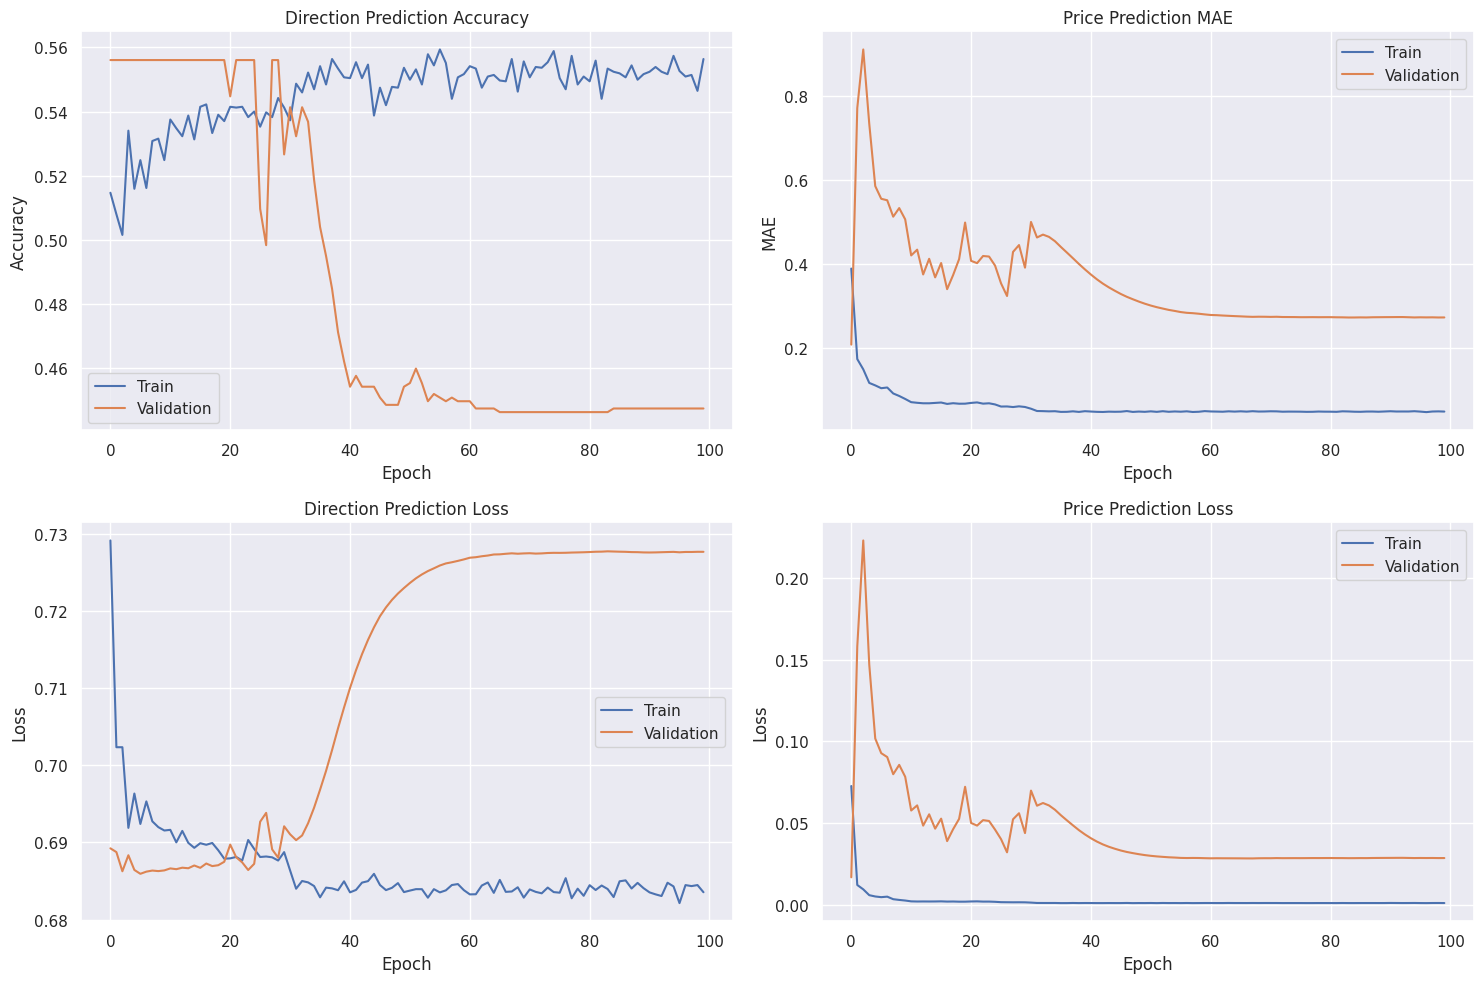

In [ ]:
model, history, _, _ = main_part2_training_evaluation(optimization_results)



=== Building and Training Final Model ===


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 60, 5)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_15          │ (None, 60, 540)        │        448,740 │ input_layer_5[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_20    │ (None, 60, 540)        │          2,160 │ bidirectional_15[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout)      │ (None, 60, 540)        │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_16          │ (None, 60, 348)        │        747,504 │ dropout_20[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 60, 348)        │          1,392 │ bidirectional_16[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_21 (Dropout)      │ (None, 60, 348)        │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_17          │ (None, 60, 176)        │        231,264 │ dropout_21[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_25 (Dense)          │ (None, 60, 1)          │            177 │ bidirectional_17[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 60)             │              0 │ dense_25[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_5 (Activation) │ (None, 60)             │              0 │ flatten_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector_5           │ (None, 176, 60)        │              0 │ activation_5[0][0]     │
│ (RepeatVector)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_5 (Permute)       │ (None, 60, 176)        │              0 │ repeat_vector_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_5 (Multiply)     │ (None, 60, 176)        │              0 │ bidirectional_17[0][0… │
│                           │                        │                │ permute_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_5 (Lambda)         │ (None, 176)            │              0 │ multiply_5[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2

 Total params: 1,446,695 (5.52 MB)

 Trainable params: 1,444,439 (5.51 MB)

 Non-trainable params: 2,256 (8.81 KB)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - direction_output_accuracy: 0.4929 - direction_output_loss: 0.7679 - direction_output_precision_5: 0.5096 - direction_output_recall_5: 0.5695 - loss: 0.9363 - price_output_loss: 0.1677 - price_output_mae: 0.6574 - price_output_mse: 0.8380 - val_direction_output_accuracy: 0.5561 - val_direction_output_loss: 0.7066 - val_direction_output_precision_5: 0.5561 - val_direction_output_recall_5: 1.0000 - val_loss: 0.7572 - val_price_output_loss: 0.0522 - val_price_output_mae: 0.4078 - val_price_output_mse: 0.1950 - learning_rate: 0.0050
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - direction_output_accuracy: 0.5098 - direction_output_loss: 0.7063 - direction_output_precision_5: 0.5215 - direction_output_recall_5: 0.6544 - loss: 0.7195 - price_output_loss: 0.0132 - price_output_mae: 0.1778 - price_output_mse: 0.0528 - val_direction_output_accuracy: 0.5561 - val_direction_output_loss: 0.6865 - val_direction_output_precision_5: 0.556

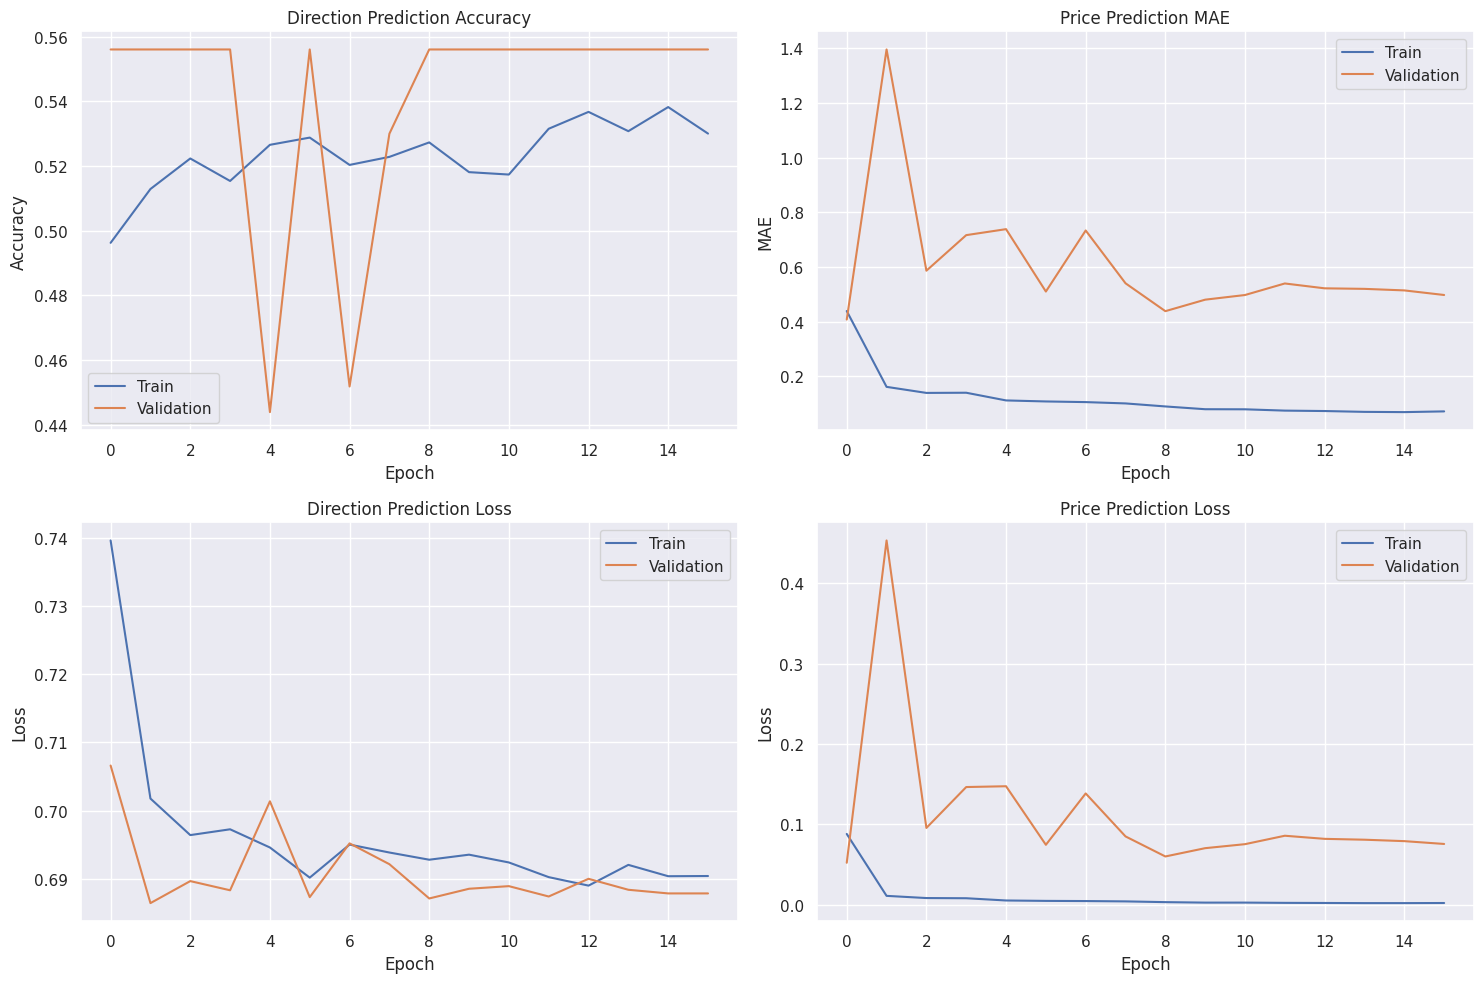

In [ ]:
model, history, _, _ = main_part2_training_evaluation(optimization_results)



=== Evaluating Model on Test Set ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - direction_output_accuracy: 0.5421 - direction_output_loss: 0.7149 - direction_output_precision_5: 0.5421 - direction_output_recall_5: 1.0000 - loss: 1.2017 - price_output_loss: 0.5335 - price_output_mae: 1.4584 - price_output_mse: 2.3544

Test Results:
loss: 1.2577
compile_metrics: 0.7136
direction_output_loss: 0.6376
price_output_loss: 0.5388

===== PERFORMANCE EVALUATION =====

Direction Prediction Metrics:
Accuracy:  0.5388
Precision: 0.5388
Recall:    1.0000
F1 Score:  0.7003

Price Prediction Metrics:
MAE:       2280.5630
RMSE:      2402.4504
MAPE:      51.2953%

Consistency Metrics:
Direction-Price Consistency: 0.2918

Market Volatility: 0.1764

===== DETAILED ERROR METRICS =====

Training Set:
MSE:  107330.2188
RMSE: 327.6129
MAE:  253.5927

Validation Set:
MSE:  412430.0000
RMSE: 642.2072
MAE:  592.9918

Test Set:
MSE:  5771768.0000
RMSE: 2402.4504
MAE:  2280.5630

=== Running Trading Simulation ===
E

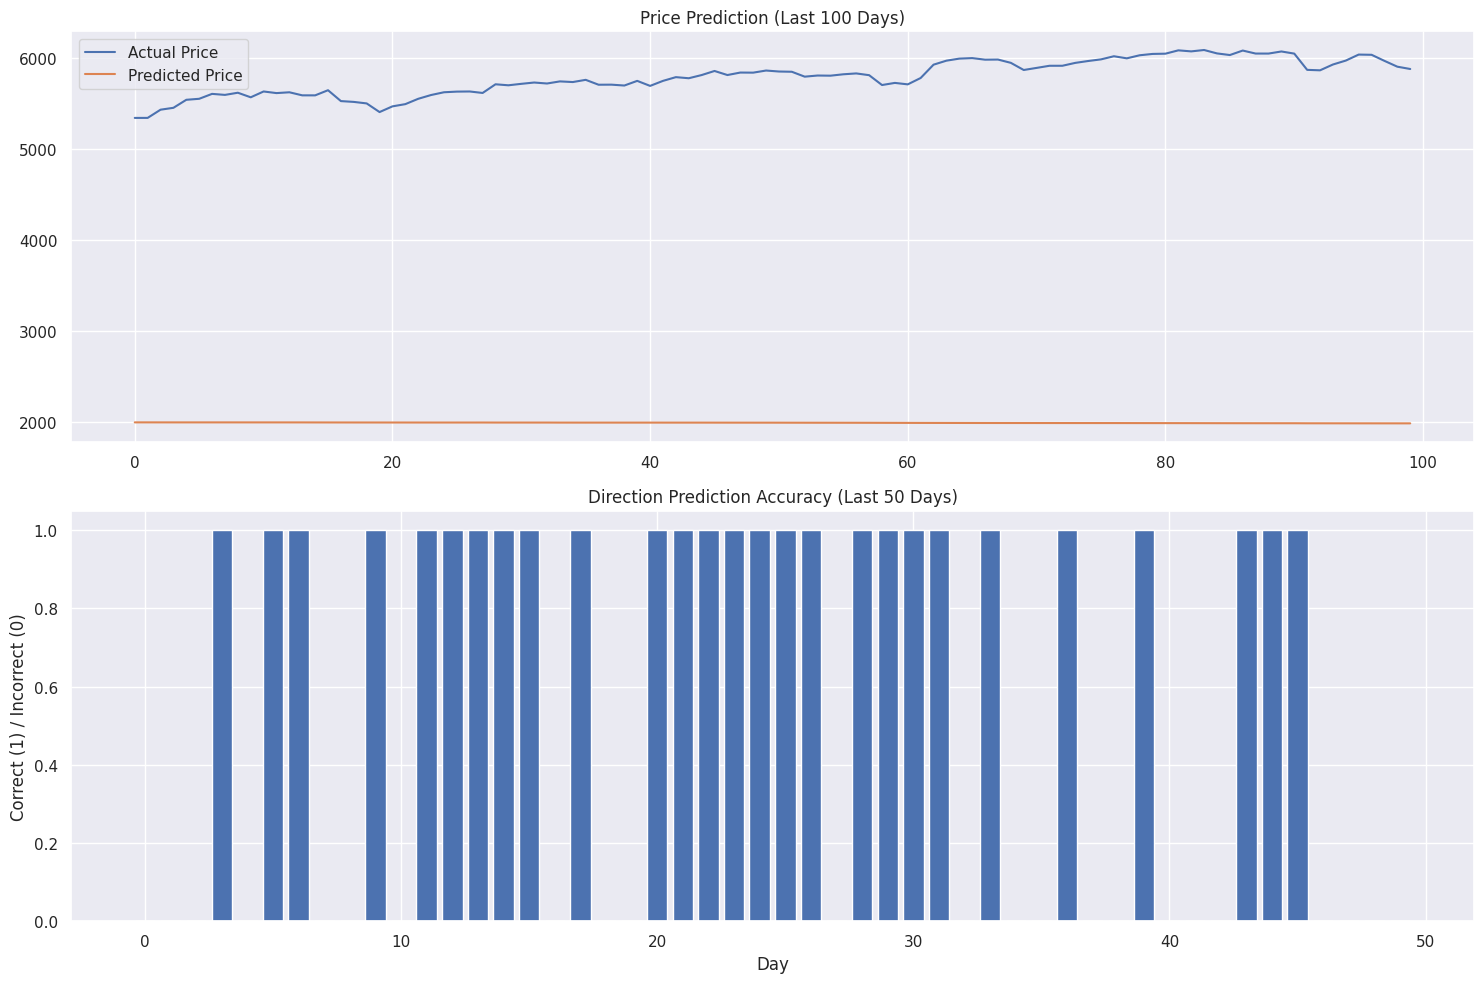

In [ ]:
 # Unpack necessary values for evaluation latest
(X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     best_params, feature_scaler, price_scaler,
     train_data_enhanced, valid_data_enhanced, test_data_enhanced,
     sequence_length, prediction_horizon) = optimization_results

    # Run evaluation part (may fail but won't affect training or optimization)
eval_results, trading_metrics, trading_data = main_part3_evaluation(
        model, train_data_enhanced, test_data_enhanced, X_test,
        y_test_dir, y_test_price, price_scaler, sequence_length, prediction_horizon
    )

TensorFlow GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train data: 4087 samples, from 2000-01-03 00:00:00 to 2016-04-01 00:00:00
Validation data: 944 samples, from 2016-04-04 00:00:00 to 2019-12-31 00:00:00
Test data: 1258 samples, from 2020-01-02 00:00:00 to 2024-12-31 00:00:00

=== Preparing Data for Modeling ===
Preparing data with sequence length 60...
Train data shape: (4026, 60, 5)
Validation data shape: (883, 60, 5)
Test data shape: (1197, 60, 5)


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)



=== Running ARO Hyperparameter Optimization ===
Starting ARO optimization with enhanced exploration...
Iteration 1/25, Best Fitness: 0.5817
Iteration 2/25, Best Fitness: 0.5817
Iteration 3/25, Best Fitness: 0.5817
Iteration 4/25, Best Fitness: 0.5817
Iteration 5/25, Best Fitness: 0.5817
Iteration 6/25, Best Fitness: 0.5817
Iteration 7/25, Best Fitness: 0.5817
Iteration 8/25, Best Fitness: 0.5817
Iteration 9/25, Best Fitness: 0.5817
Iteration 10/25, Best Fitness: 0.5817
Iteration 11/25, Best Fitness: 0.5817
Iteration 12/25, Best Fitness: 0.5817
Iteration 13/25, Best Fitness: 0.5817
Iteration 14/25, Best Fitness: 0.5817
Iteration 15/25, Best Fitness: 0.5817
Iteration 16/25, Best Fitness: 0.5817
Iteration 17/25, Best Fitness: 0.5817
Iteration 18/25, Best Fitness: 0.5817
Iteration 19/25, Best Fitness: 0.5817
Iteration 20/25, Best Fitness: 0.5817
Iteration 21/25, Best Fitness: 0.5817
Iteration 22/25, Best Fitness: 0.5817
Iteration 23/25, Best Fitness: 0.5817
Iteration 24/25, Best Fitness: 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 60, 5)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 60, 434)        │        291,648 │ input_layer[0][0]      │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 60, 434)        │          1,736 │ bidirectional[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 60, 434)        │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 60, 196)        │        313,992 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 60, 196)        │            784 │ bidirectional_1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 60, 196)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 106)            │         79,818 │ dropout_1[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 106)            │            424 │ bidirectional_2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 106)            │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          6,848 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64)             │            256 │ dense[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 64)             │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │          2,080 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 16)             │            528 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 16)             │            528 │ dense_1[0][0]          │
├──────────────────────

 Total params: 698,676 (2.67 MB)

 Trainable params: 697,076 (2.66 MB)

 Non-trainable params: 1,600 (6.25 KB)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - direction_output_accuracy: 0.5030 - direction_output_loss: 0.7198 - direction_output_precision: 0.5111 - direction_output_recall: 0.5695 - loss: 1.0880 - price_output_loss: 0.3675 - price_output_mae: 0.6228 - price_output_mse: 0.7362 - val_direction_output_accuracy: 0.5561 - val_direction_output_loss: 0.6876 - val_direction_output_precision: 0.5561 - val_direction_output_recall: 1.0000 - val_loss: 0.7163 - val_price_output_loss: 0.0333 - val_price_output_mae: 0.1971 - val_price_output_mse: 0.0561 - learning_rate: 0.0087
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - direction_output_accuracy: 0.5006 - direction_output_loss: 0.7015 - direction_output_precision: 0.5139 - direction_output_recall: 0.6296 - loss: 0.7184 - price_output_loss: 0.0169 - price_output_mae: 0.1417 - price_output_mse: 0.0337 - val_direction_output_accuracy: 0.4439 - val_direction_output_loss: 0.7020 - val_direction_output_precision: 0.0000e+00 - val_dire

NameError: name 'precision_score' is not defined

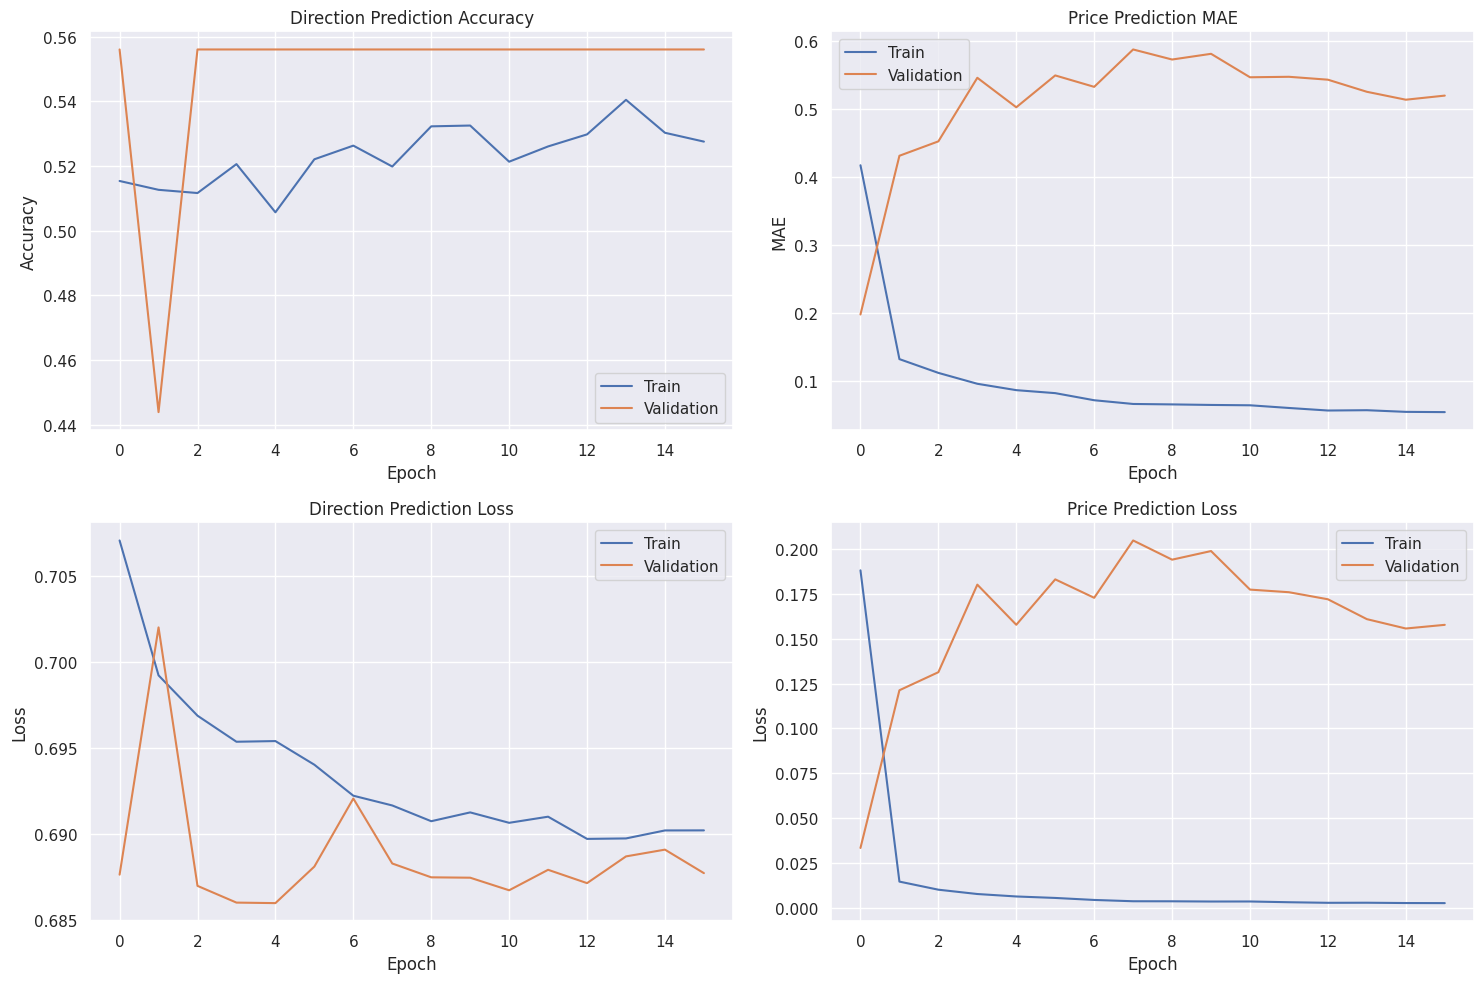

In [ ]:
# Run the model with GPUs
if __name__ == "__main__":
    # Check GPU availability
    print("TensorFlow GPU available:", tf.config.list_physical_devices('GPU'))

    # Example usage:
    model, results, metrics, trading_data = main(train_data, valid_data, test_data)

### Trading Simulation for the hybrid model

In [ ]:
def run_and_display_trading_simulation(model, test_data_enhanced, X_test, y_test_dir, y_test_price, price_scaler, sequence_length, prediction_horizon):
    """
    Run trading simulation separately and display detailed results
    """
    try:
        # Make predictions
        test_predictions = model.predict(X_test, batch_size=512, verbose=0)
        y_pred_dir_probs = test_predictions[0].flatten()
        y_pred_price_scaled = test_predictions[1]

        # Convert direction probabilities to binary predictions
        y_pred_dir = (y_pred_dir_probs > 0.5).astype(int)

        # Inverse transform the price predictions
        y_pred_price = price_scaler.inverse_transform(y_pred_price_scaled).flatten()
        y_test_price_actual = price_scaler.inverse_transform(y_test_price.reshape(-1, 1)).flatten()

        # Prepare test data for trading simulation
        test_data_for_trading = test_data_enhanced.iloc[sequence_length:len(test_data_enhanced)-prediction_horizon+1]

        if len(test_data_for_trading) != len(y_pred_dir):
            print(f"Warning: Length mismatch - test_data: {len(test_data_for_trading)}, predictions: {len(y_pred_dir)}")
            min_length = min(len(test_data_for_trading), len(y_pred_dir))
            test_data_for_trading = test_data_for_trading.iloc[:min_length]
            y_pred_dir = y_pred_dir[:min_length]
            y_pred_dir_probs = y_pred_dir_probs[:min_length]
            y_pred_price = y_pred_price[:min_length]
            print(f"Adjusted data length to {min_length}")

        print("\n=== Running Trading Simulation ===")
        trading_data, trading_metrics = simulate_dual_trading(
            y_pred_dir,
            y_pred_dir_probs,
            y_pred_price,
            test_data_for_trading
        )

        print("\n===== DETAILED TRADING RESULTS =====")
        print(f"\nOverall Performance:")
        print(f"Total Return:         {trading_metrics['total_return']:.4f} (Market: {trading_metrics['market_return']:.4f})")
        print(f"Annualized Return:    {trading_metrics['ann_return']:.4f} (Market: {trading_metrics['ann_market_return']:.4f})")

        print(f"\nRisk Metrics:")
        print(f"Maximum Drawdown:     {trading_metrics['max_drawdown']:.4f} (Market: {trading_metrics['market_drawdown']:.4f})")
        print(f"Sharpe Ratio:         {trading_metrics['sharpe_ratio']:.4f}")
        print(f"Sortino Ratio:        {trading_metrics['sortino_ratio']:.4f}")

        print(f"\nTrade Statistics:")
        print(f"Win Rate:             {trading_metrics['win_rate']:.4f}")
        print(f"Profit Factor:        {trading_metrics['profit_factor']:.4f}")

        # Calculate additional metrics
        total_trades = len(trading_data)
        winning_trades = sum(trading_data['Strategy_Return'] > 0)
        losing_trades = sum(trading_data['Strategy_Return'] < 0)
        largest_win = trading_data['Strategy_Return'].max()
        largest_loss = trading_data['Strategy_Return'].min()

        if winning_trades > 0:
            avg_win = trading_data.loc[trading_data['Strategy_Return'] > 0, 'Strategy_Return'].mean()
        else:
            avg_win = 0

        if losing_trades > 0:
            avg_loss = trading_data.loc[trading_data['Strategy_Return'] < 0, 'Strategy_Return'].mean()
        else:
            avg_loss = 0

        # Calculate win percentage
        win_percentage = (winning_trades/total_trades*100) if total_trades > 0 else 0
        loss_percentage = (losing_trades/total_trades*100) if total_trades > 0 else 0
        win_loss_ratio = abs(avg_win/avg_loss) if avg_loss != 0 else "N/A"

        print(f"\nAdditional Statistics:")
        print(f"Total Trades:         {total_trades}")
        print(f"Winning Trades:       {winning_trades} ({win_percentage:.2f}%)")
        print(f"Losing Trades:        {losing_trades} ({loss_percentage:.2f}%)")
        print(f"Largest Win:          {largest_win:.4f}")
        print(f"Largest Loss:         {largest_loss:.4f}")
        print(f"Average Win:          {avg_win:.4f}")
        print(f"Average Loss:         {avg_loss:.4f}")
        print(f"Win/Loss Ratio:       {win_loss_ratio}")

        # Display trading performance by year
        trading_data['Year'] = trading_data.index.year
        print("\nPerformance By Year:")
        yearly_returns = trading_data.groupby('Year')['Strategy_Return'].sum()
        yearly_market_returns = trading_data.groupby('Year')['Return'].sum()

        for year in yearly_returns.index:
            print(f"{year}: {yearly_returns[year]:.4f} (Market: {yearly_market_returns[year]:.4f})")

        # Display additional plots
        plt.figure(figsize=(15, 15))

        # Plot monthly returns
        trading_data['Month'] = trading_data.index.to_period('M')
        monthly_returns = trading_data.groupby('Month')['Strategy_Return'].sum()
        monthly_market = trading_data.groupby('Month')['Return'].sum()

        plt.subplot(3, 1, 1)
        monthly_returns.plot(kind='bar', color='blue', alpha=0.7, label='Strategy')
        monthly_market.plot(kind='bar', color='red', alpha=0.5, label='Market')
        plt.title('Monthly Returns')
        plt.ylabel('Monthly Return')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot drawdown underwater chart
        plt.subplot(3, 1, 2)
        plt.fill_between(trading_data.index, 0, trading_data['Strategy_Drawdown'], color='red', alpha=0.5)
        plt.title('Drawdown Underwater Chart')
        plt.ylabel('Drawdown')
        plt.grid(True)

        # Plot rolling Sharpe ratio (6-month window)
        plt.subplot(3, 1, 3)
        excess_returns = trading_data['Strategy_Return'] - trading_data['Return']
        # Use smaller window if data is short
        window_size = min(126, len(trading_data) // 4)
        if window_size > 0:
            rolling_sharpe = excess_returns.rolling(window=window_size).mean() / excess_returns.rolling(window=window_size).std() * np.sqrt(252)
            plt.plot(rolling_sharpe, color='green')
            plt.title(f'{window_size}-Day Rolling Sharpe Ratio')
        else:
            plt.title('Not enough data for rolling Sharpe calculation')
        plt.ylabel('Sharpe Ratio')
        plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        plt.grid(True)

        plt.tight_layout()
        plt.savefig('trading_detailed_results.png')

        # Save detailed trading results to CSV
        trading_data.to_csv('results/detailed_trading_results.csv')

        return trading_data, trading_metrics

    except Exception as e:
        print(f"Error in trading simulation: {e}")
        import traceback
        traceback.print_exc()  # Print full stack trace for debugging
        return None, None


===== RUNNING SEPARATE TRADING SIMULATION =====
Adjusted data length to 1197

=== Running Trading Simulation ===

===== TRADING PERFORMANCE =====
Total Return:         0.1721 (Market: 1.2488)
Annualized Return:    0.0340 (Market: 0.1859)
Max Drawdown:         -0.0388 (Market: -0.2543)
Sharpe Ratio:         0.4635
Sortino Ratio:        0.7607
Win Rate:             0.5388
Profit Factor:        1.2287


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1



===== DETAILED TRADING RESULTS =====

Overall Performance:
Total Return:         0.1721 (Market: 1.2488)
Annualized Return:    0.0340 (Market: 0.1859)

Risk Metrics:
Maximum Drawdown:     -0.0388 (Market: -0.2543)
Sharpe Ratio:         0.4635
Sortino Ratio:        0.7607

Trade Statistics:
Win Rate:             0.5388
Profit Factor:        1.2287

Additional Statistics:
Total Trades:         1197
Winning Trades:       645 (53.88%)
Losing Trades:        551 (46.03%)
Largest Win:          0.0180
Largest Loss:         -0.0117
Average Win:          0.0013
Average Loss:         -0.0013
Win/Loss Ratio:       1.0496599312267865

Performance By Year:
2020: 0.0816 (Market: 0.3776)
2021: 0.0393 (Market: 0.2468)
2022: -0.0236 (Market: -0.1871)
2023: 0.0356 (Market: 0.2255)
2024: 0.0281 (Market: 0.2219)


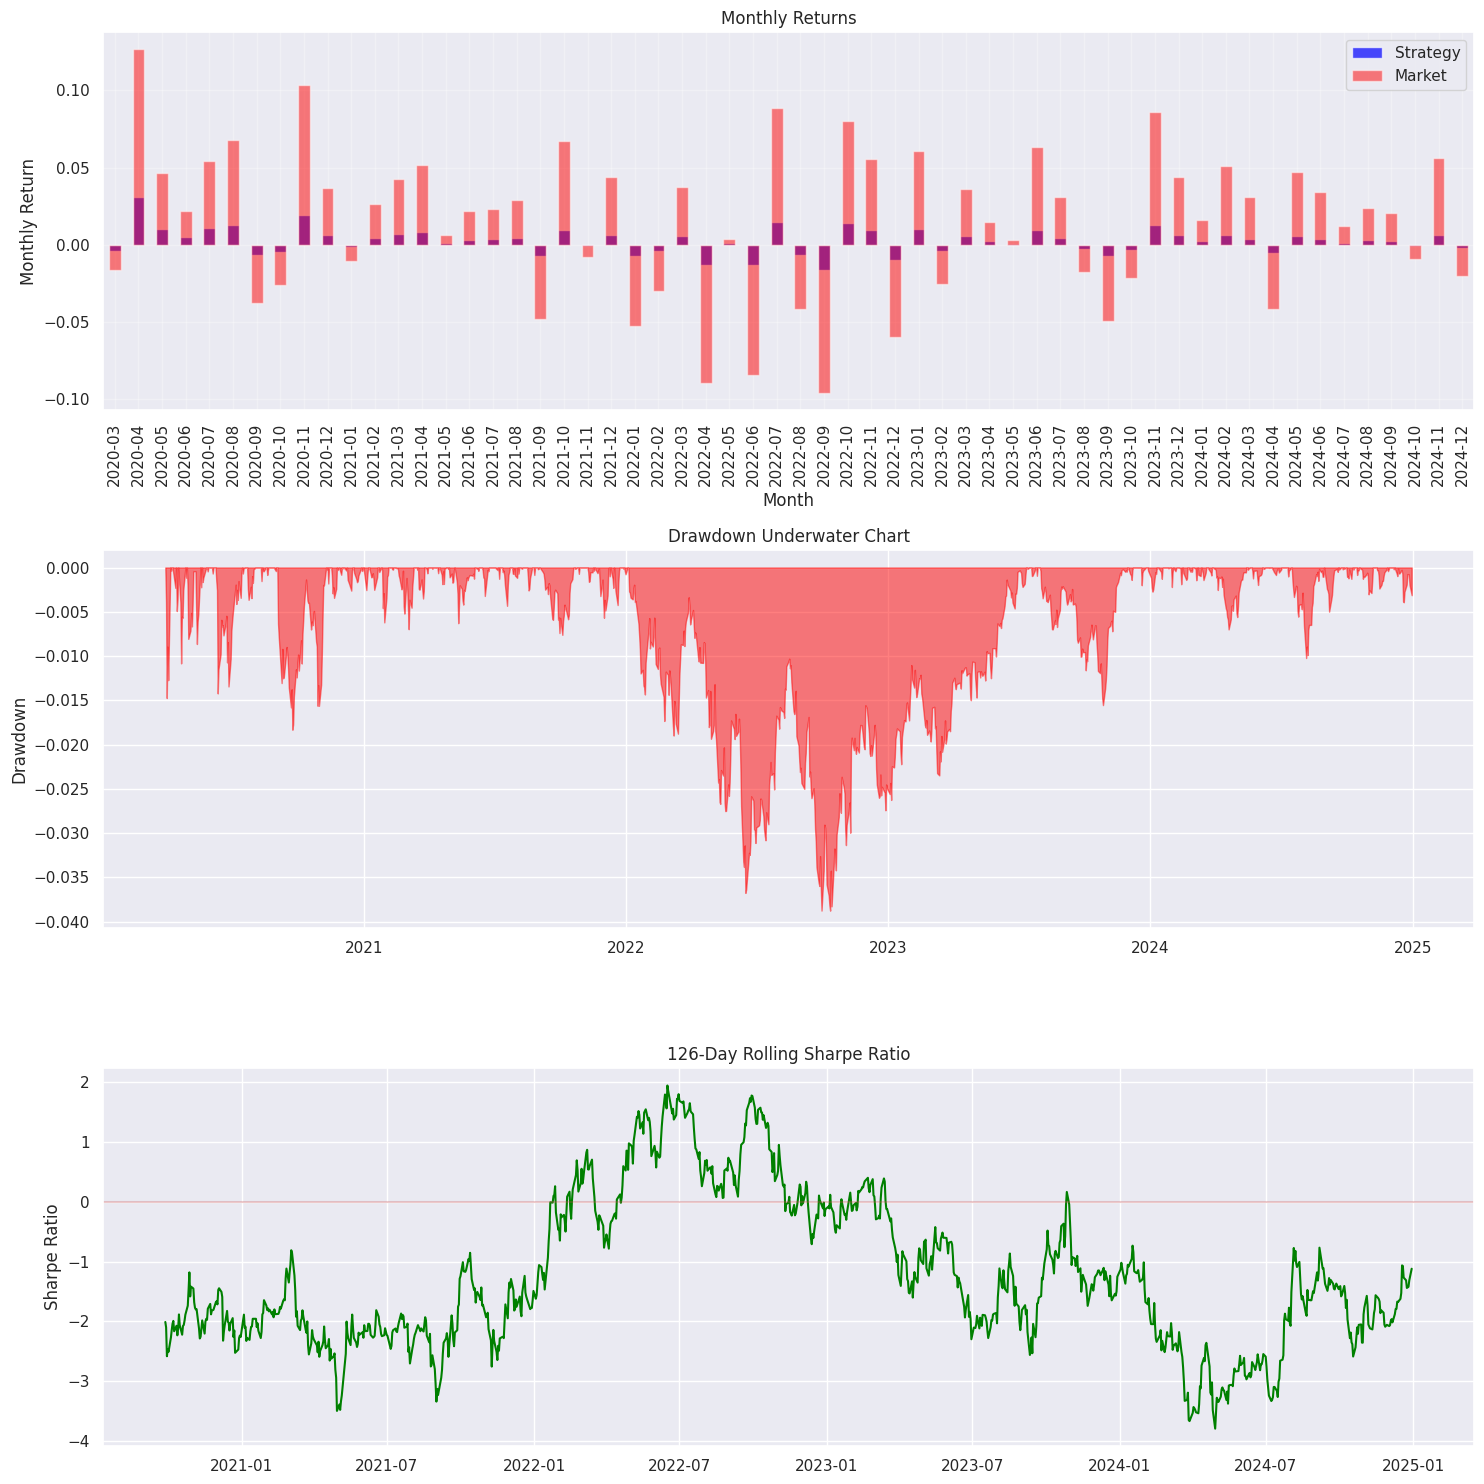

In [ ]:
# Call trading simulation separately
if model is not None:
    print("\n===== RUNNING SEPARATE TRADING SIMULATION =====")
    trading_data, trading_metrics = run_and_display_trading_simulation(
        model,
        test_data_enhanced,
        X_test,
        y_test_dir,
        y_test_price,
        price_scaler,
        sequence_length,
        prediction_horizon
    )

## Model trained with baseline two models seperately with custom loss function- ARO optimization


=== Preparing Data for Modeling ===
Train data shape: (4026, 60, 5)
Validation data shape: (883, 60, 5)
Test data shape: (1197, 60, 5)
Class distribution - Up: 2138/4026 (0.53), Down: 1888/4026 (0.47)
Class weights: {0: 1.066207627118644, 1: 0.941534144059869}

=== Building Improved Model ===


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 60, 5)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_6           │ (None, 60, 540)        │        596,160 │ input_layer[0][0]      │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 60, 540)        │          2,160 │ bidirectional_6[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 60, 540)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_7           │ (None, 60, 348)        │        995,280 │ dropout_10[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 60, 348)        │          1,392 │ bidirectional_7[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 60, 348)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_8           │ (None, 60, 176)        │        307,648 │ dropout_11[0][0]       │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 60, 64)         │         11,328 │ bidirectional_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 60, 1)          │             65 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 60)             │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_weights         │ (None, 60)             │              0 │ flatten_2[0][0]        │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector_2           │ (None, 176, 60)        │              0 │ attention_weights[0][… │
│ (RepeatVector)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_2 (Permute)       │ (None, 60, 176)        │              0 │ repeat_vector_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_2 (Multiply)     │ (None, 60, 176)        │              0 │ bidirectional_8[0][0], │
│                           │                        │                │ permute_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_2 (Lambda)    

 Total params: 1,935,219 (7.38 MB)

 Trainable params: 1,932,707 (7.37 MB)

 Non-trainable params: 2,512 (9.81 KB)


=== Training Improved Model ===
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - direction_output_accuracy: 0.4790 - direction_output_loss: 0.2394 - direction_output_precision: 0.4943 - direction_output_recall: 0.4657 - loss: 0.7218 - price_output_loss: 0.4823 - price_output_mae: 0.8533 - price_output_mse: 1.2764
Epoch 1: val_loss improved from inf to 0.57665, saving model to models/improved_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - direction_output_accuracy: 0.4794 - direction_output_loss: 0.2380 - direction_output_precision: 0.4952 - direction_output_recall: 0.4655 - loss: 0.7150 - price_output_loss: 0.4767 - price_output_mae: 0.8467 - price_output_mse: 1.2599 - val_direction_output_accuracy: 0.4439 - val_direction_output_loss: 0.0727 - val_direction_output_precision: 0.0000e+00 - val_direction_output_recall: 0.0000e+00 - val_loss: 0.5766 - val_price_output_loss: 0.5076 - val_price_output_mae: 0.9934 - val_price_output_mse: 1.0235 - learning_rate: 0.0010
Epoch 2/1

KeyError: 'lr'

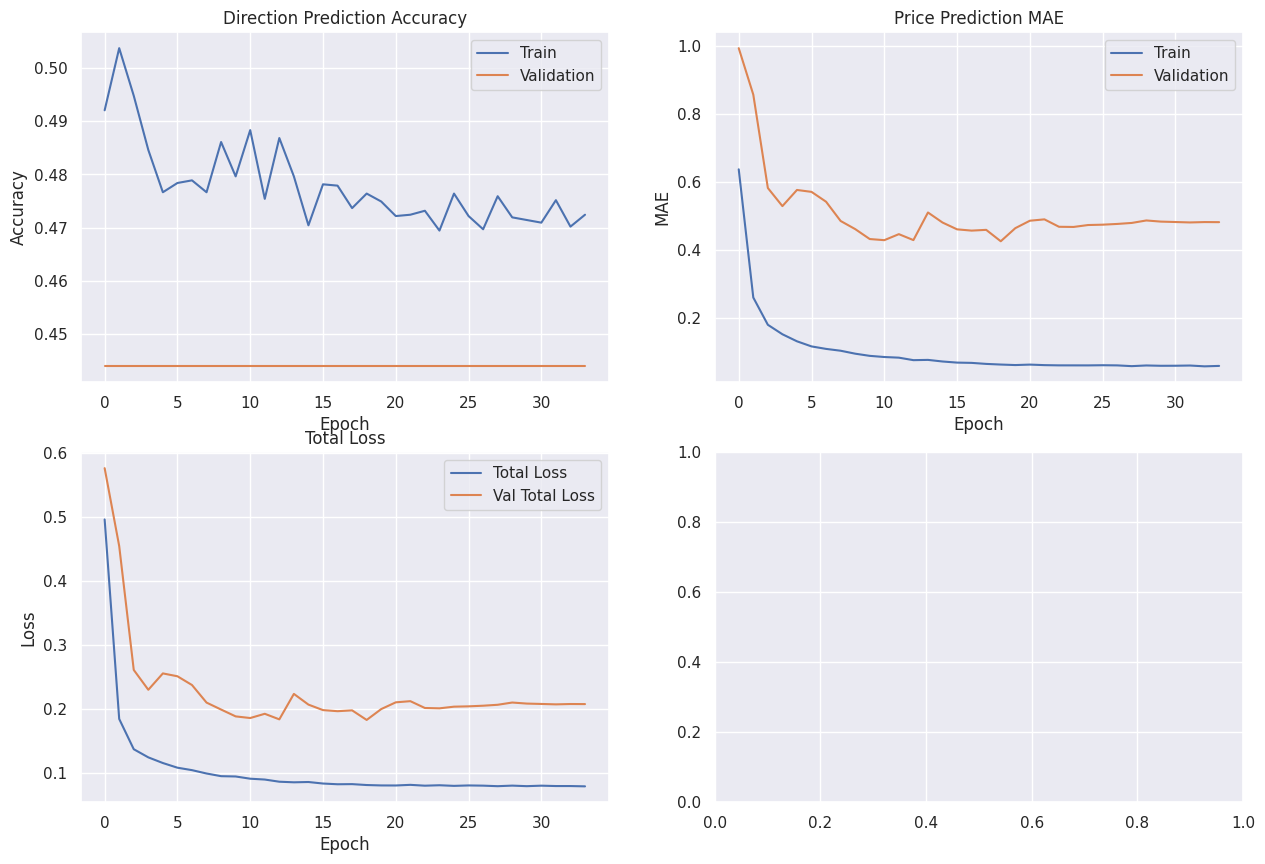

In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_factor = tf.ones_like(y_true) * alpha
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha_factor, 1 - alpha_factor)
        focal_weight = tf.multiply(alpha_factor, tf.pow(1 - pt, gamma))
        loss = tf.multiply(focal_weight, K.binary_crossentropy(y_true, y_pred))
        return tf.reduce_mean(loss)
    return focal_loss_fixed

def create_attention_layer(x):
    # Compute attention scores with tanh activation for better gradient flow
    attention = Dense(64, activation='tanh')(x)
    attention = Dense(1, activation=None)(attention)

    attention_weights = Flatten()(attention)
    attention_weights = Activation('softmax', name='attention_weights')(attention_weights)
    attention_weights = RepeatVector(K.int_shape(x)[2])(attention_weights)
    attention_weights = Permute([2, 1])(attention_weights)

    weighted_output = Multiply()([x, attention_weights])
    context_vector = Lambda(
        lambda x: K.sum(x, axis=1),
        output_shape=lambda input_shape: (input_shape[0], input_shape[2])
    )(weighted_output)
    return context_vector, attention_weights

def build_improved_model(input_shape, use_bidirectional=True,
                         lstm_units=[256, 128, 64],
                         dropout_rates=[0.3, 0.3, 0.3],
                         learning_rate=0.001,
                         use_attention=True,
                         class_weights=None):
    """  Build an improved dual-output LSTM model with attention. """
    inputs = Input(shape=input_shape, name='input_layer')

    # First LSTM layer
    if use_bidirectional:
        x = Bidirectional(LSTM(lstm_units[0], return_sequences=True,
                             activation='tanh',
                             recurrent_activation='sigmoid',
                             recurrent_dropout=0.0))(inputs)
    else:
        x = LSTM(lstm_units[0], return_sequences=True,
               activation='tanh',
               recurrent_activation='sigmoid',
               recurrent_dropout=0.0)(inputs)

    x = BatchNormalization()(x)
    x = Dropout(dropout_rates[0])(x)

    # Second LSTM layer
    if use_bidirectional:
        x = Bidirectional(LSTM(lstm_units[1], return_sequences=True,
                             activation='tanh',
                             recurrent_activation='sigmoid',
                             recurrent_dropout=0.0))(x)
    else:
        x = LSTM(lstm_units[1], return_sequences=True,
               activation='tanh',
               recurrent_activation='sigmoid',
               recurrent_dropout=0.0)(x)

    x = BatchNormalization()(x)
    x = Dropout(dropout_rates[1])(x)

    # Third LSTM layer with attention
    if use_bidirectional:
        x = Bidirectional(LSTM(lstm_units[2], return_sequences=use_attention,
                             activation='tanh',
                             recurrent_activation='sigmoid',
                             recurrent_dropout=0.0))(x)
    else:
        x = LSTM(lstm_units[2], return_sequences=use_attention,
               activation='tanh',
               recurrent_activation='sigmoid',
               recurrent_dropout=0.0)(x)

    if use_attention:
        context_vector, attention_weights = create_attention_layer(x)
        x = context_vector

    x = BatchNormalization()(x)
    x = Dropout(dropout_rates[2])(x)

    shared = Dense(64, activation='relu')(x)
    shared = BatchNormalization()(shared)
    shared = Dropout(0.2)(shared)

    # Price branch - more complex for better regression
    price_branch = Dense(64, activation='relu')(shared)
    price_branch = BatchNormalization()(price_branch)
    price_branch = Dense(32, activation='relu')(price_branch)
    price_branch = BatchNormalization()(price_branch)
    price_output = Dense(1, activation='linear', name='price_output')(price_branch)

    # Direction branch
    direction_branch = Dense(32, activation='relu')(shared)
    direction_branch = BatchNormalization()(direction_branch)
    direction_branch = Dropout(0.2)(direction_branch)
    direction_output = Dense(1, activation='sigmoid', name='direction_output')(direction_branch)

    # Create model
    model = Model(inputs=inputs, outputs=[direction_output, price_output])

    focal_loss_fn = focal_loss(gamma=2.0, alpha=0.25)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss={
            'direction_output': focal_loss_fn,
            'price_output': 'huber'
        },
        loss_weights={
            'direction_output': 1.0,
            'price_output': 1.0
        },
        metrics={
            'direction_output': ['accuracy',
                               tf.keras.metrics.Precision(name='precision'),
                               tf.keras.metrics.Recall(name='recall')],
            'price_output': ['mae', 'mse']
        }
    )

    return model

def train_model(model, X_train, y_train_dir, y_train_price,
                X_val, y_val_dir, y_val_price,
                batch_size=64, epochs=100,
                class_weight=None, save_path='best_model_hybrid.keras'):

    """ Train the model with improved callbacks and learning rate scheduling """

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    model_checkpoint = ModelCheckpoint(
        filepath=save_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )


    if class_weight is not None:
        sample_weights = np.ones(len(y_train_dir))
        for cls, weight in class_weight.items():
            sample_weights[y_train_dir == cls] = weight
    else:
        sample_weights = None

    history = model.fit(
        X_train,
        {'direction_output': y_train_dir, 'price_output': y_train_price},
        validation_data=(X_val, {'direction_output': y_val_dir, 'price_output': y_val_price}),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, model_checkpoint, reduce_lr],
        verbose=1,
        sample_weight=sample_weights
    )

    return history

def prepare_custom_data(train_data, valid_data, test_data, sequence_length=60, prediction_horizon=1):
    """ Data preparation function with proper scaling. """
    from sklearn.preprocessing import MinMaxScaler, StandardScaler

    train_data = train_data.copy()
    valid_data = valid_data.copy()
    test_data = test_data.copy()

    for df in [train_data, valid_data, test_data]:
        if 'Next_Day_Direction' not in df.columns:
            df['Next_Day_Direction'] = (df['Close'].shift(-prediction_horizon) > df['Close']).astype(int)
        if 'Next_Day_Price' not in df.columns:
            df['Next_Day_Price'] = df['Close'].shift(-prediction_horizon)

    train_data = train_data.dropna()
    valid_data = valid_data.dropna()
    test_data = test_data.dropna()

    direction_col = 'Next_Day_Direction'
    price_col = 'Next_Day_Price'

    feature_cols = [col for col in train_data.columns if col not in [direction_col, price_col]]

    feature_scaler = StandardScaler()
    price_scaler = MinMaxScaler(feature_range=(0, 1))

    feature_scaler.fit(train_data[feature_cols])
    price_scaler.fit(train_data[[price_col]])

    # Transform features
    scaled_train_features = feature_scaler.transform(train_data[feature_cols])
    scaled_valid_features = feature_scaler.transform(valid_data[feature_cols])
    scaled_test_features = feature_scaler.transform(test_data[feature_cols])

    # Transform price targets
    scaled_train_prices = price_scaler.transform(train_data[[price_col]]).flatten()
    scaled_valid_prices = price_scaler.transform(valid_data[[price_col]]).flatten()
    scaled_test_prices = price_scaler.transform(test_data[[price_col]]).flatten()

    def create_sequences(features, direction_values, price_values, seq_length):
        total_sequences = len(features) - seq_length - prediction_horizon + 1
        X = np.zeros((total_sequences, seq_length, features.shape[1]), dtype=np.float32)
        y_dir = np.zeros(total_sequences, dtype=np.int32)
        y_price = np.zeros(total_sequences, dtype=np.float32)

        for i in range(total_sequences):
            X[i] = features[i:i+seq_length]
            idx = i + seq_length + prediction_horizon - 1
            if idx < len(direction_values):
                y_dir[i] = direction_values[idx]
                y_price[i] = price_values[idx]

        return X, y_dir, y_price

    train_dir = train_data[direction_col].values
    valid_dir = valid_data[direction_col].values
    test_dir = test_data[direction_col].values

    X_train, y_train_dir, y_train_price = create_sequences(
        scaled_train_features, train_dir, scaled_train_prices, sequence_length
    )
    X_val, y_val_dir, y_val_price = create_sequences(
        scaled_valid_features, valid_dir, scaled_valid_prices, sequence_length
    )
    X_test, y_test_dir, y_test_price = create_sequences(
        scaled_test_features, test_dir, scaled_test_prices, sequence_length
    )

    print(f"Train data shape: {X_train.shape}")
    print(f"Validation data shape: {X_val.shape}")
    print(f"Test data shape: {X_test.shape}")

    total_samples = len(y_train_dir)
    n_positive = np.sum(y_train_dir)
    n_negative = total_samples - n_positive

    class_weight = {
        0: total_samples / (2.0 * n_negative),
        1: total_samples / (2.0 * n_positive)
    }

    print(f"Class distribution - Up: {n_positive}/{total_samples} ({n_positive/total_samples:.2f}), "
          f"Down: {n_negative}/{total_samples} ({n_negative/total_samples:.2f})")
    print(f"Class weights: {class_weight}")

    return (X_train, y_train_dir, y_train_price,
            X_val, y_val_dir, y_val_price,
            X_test, y_test_dir, y_test_price,
            feature_scaler, price_scaler, feature_cols, class_weight)

def evaluate_model(model, X_test, y_test_dir, y_test_price, price_scaler):
    """ Evaluate model performance with proper price scaling """

    dir_pred, price_pred = model.predict(X_test)
    y_pred_dir = (dir_pred > 0.5).astype(int).flatten()

    # Inverse transform price predictions to get original scale
    y_pred_price_inv = price_scaler.inverse_transform(price_pred).flatten()
    y_test_price_inv = price_scaler.inverse_transform(y_test_price.reshape(-1, 1)).flatten()
    accuracy = accuracy_score(y_test_dir, y_pred_dir)
    precision = precision_score(y_test_dir, y_pred_dir)
    recall = recall_score(y_test_dir, y_pred_dir)
    f1 = f1_score(y_test_dir, y_pred_dir)

    mae = mean_absolute_error(y_test_price_inv, y_pred_price_inv)
    mse = mean_squared_error(y_test_price_inv, y_pred_price_inv)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test_price_inv - y_pred_price_inv) / y_test_price_inv)) * 100

    print("==== Model Evaluation ====")
    print("\nDirection Prediction Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\nPrice Prediction Metrics:")
    print(f"MAE:       {mae:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print(f"MAPE:      {mape:.4f}%")

    price_direction = (y_pred_price_inv[1:] > y_pred_price_inv[:-1]).astype(int)
    dir_consistency = np.mean(price_direction == y_pred_dir[1:])
    print(f"\nDirection-Price Consistency: {dir_consistency:.4f}")
    cm = confusion_matrix(y_test_dir, y_pred_dir)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 1, 1)
    plt.plot(y_test_price_inv[-100:], 'b-', label='Actual Price')
    plt.plot(y_pred_price_inv[-100:], 'r-', label='Predicted Price')
    plt.title('Price Prediction (Last 100 Days)')
    plt.legend()
    plt.grid(True)

    # Plot direction accuracy
    plt.subplot(2, 1, 2)
    correct = (y_pred_dir == y_test_dir).astype(int)
    plt.bar(range(len(correct[-50:])), correct[-50:])
    plt.title('Direction Prediction Accuracy (Last 50 Days)')
    plt.xlabel('Day Index')
    plt.ylabel('Correct (1) / Incorrect (0)')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('model_evaluation.png')
    plt.close()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'dir_consistency': dir_consistency,
        'y_pred_dir': y_pred_dir,
        'y_pred_price': y_pred_price_inv,
        'y_true_dir': y_test_dir,
        'y_true_price': y_test_price_inv
    }

def main():

    os.makedirs('models', exist_ok=True)
    os.makedirs('results', exist_ok=True)
    sequence_length = 60
    prediction_horizon = 1

    print("\n=== Preparing Data for Modeling ===")
    (X_train, y_train_dir, y_train_price,
     X_val, y_val_dir, y_val_price,
     X_test, y_test_dir, y_test_price,
     feature_scaler, price_scaler, feature_cols, class_weight) = prepare_custom_data(
        train_data, valid_data, test_data,
        sequence_length=sequence_length,
        prediction_horizon=prediction_horizon
    )

    input_shape = (X_train.shape[1], X_train.shape[2])
    lstm_units = [270, 174, 88]
    dropout_rates = [0.3, 0.3, 0.3]
    learning_rate = 0.001
    batch_size = 128

    print("\n=== Building Improved Model ===")
    model = build_improved_model(
        input_shape=input_shape,
        use_bidirectional=True,
        lstm_units=lstm_units,
        dropout_rates=dropout_rates,
        learning_rate=learning_rate,
        use_attention=True
    )

    model.summary()
    print("\n=== Training Improved Model ===")
    history = train_model(
        model=model,
        X_train=X_train,
        y_train_dir=y_train_dir,
        y_train_price=y_train_price,
        X_val=X_val,
        y_val_dir=y_val_dir,
        y_val_price=y_val_price,
        batch_size=batch_size,
        epochs=100,
        class_weight=class_weight,
        save_path='models/improved_model.keras'
    )

    plt.figure(figsize=(15, 10))

    # Plot direction accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history.history['direction_output_accuracy'], label='Train')
    plt.plot(history.history['val_direction_output_accuracy'], label='Validation')
    plt.title('Direction Prediction Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot price MAE
    plt.subplot(2, 2, 2)
    plt.plot(history.history['price_output_mae'], label='Train')
    plt.plot(history.history['val_price_output_mae'], label='Validation')
    plt.title('Price Prediction MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    # Plot losses
    plt.subplot(2, 2, 3)
    plt.plot(history.history['loss'], label='Total Loss')
    plt.plot(history.history['val_loss'], label='Val Total Loss')
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot learning rate
    plt.subplot(2, 2, 4)
    plt.semilogy(history.history['lr'], label='Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate (log scale)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('results/training_history.png')
    plt.close()

    print("\n=== Evaluating Model ===")
    eval_results = evaluate_model(model, X_test, y_test_dir, y_test_price, price_scaler)

    with open('results/evaluation_metrics.json', 'w') as f:
        metrics_to_save = {k: v for k, v in eval_results.items()
                          if not isinstance(v, np.ndarray)}
        json.dump(metrics_to_save, f, indent=4)

    print("\n=== Model Training and Evaluation Complete ===")
    return model, history, eval_results

if __name__ == "__main__":
    main()

### Predict the output with above lstm model and

In [ ]:
import shutil

# Define the directory you want to zip
source_dir = '/kaggle/working'

# Define the name of the zip file
output_filename = '/kaggle/working/kaggle_files_backup_latest_15april'

# Create a zip archive of your files
shutil.make_archive(output_filename, 'zip', source_dir)

print("Zip file created successfully!")


Zip file created successfully!


In [ ]:
rm *.zip
